In [1]:
from dask.distributed import Client, progress
from dask_jobqueue import SLURMCluster
import os
import warnings
warnings.filterwarnings("ignore")

cluster = SLURMCluster(cores=36, memory='180GB',
                project='science', walltime='08:00:00', queue='compute', interface='ib0')
# workers = cluster.start_workers(1)
# print(cluster.job_script())
client = Client(cluster)

import numpy as np
from matplotlib import pyplot as plt
import netCDF4 as nc
from cmocean import cm
import cartopy
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import cartopy.mpl.ticker as cticker
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.interpolate import griddata
from datetime import date
import geopy
import geopy.distance
import seawater as sw
import xarray as xr
from matplotlib.patches import Rectangle
from datetime import datetime, timedelta
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D
# import pyroms
# import pyroms_toolbox
# from pyroms.hgrid import *
# from pyroms.vgrid import *
# from pyroms.grid import *
# from pyroms import io
import pandas as pd 
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from scipy.signal import find_peaks
import scipy.signal as signal
from scipy.stats import linregress
from scipy.signal import medfilt, detrend
from astropy.convolution import Box1DKernel,Box2DKernel,convolve
from matplotlib import patches
from matplotlib.collections import PatchCollection
import calendar
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import netCDF4
import scipy.io as sio
from scipy import stats
from matplotlib import gridspec
from matplotlib import patches

outpath = '/user/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis/'

roms_path = '/proj/cdx/ykwon/downscaled/'
glorys_path = '/proj/cmip6/data/ocean_reanalysis/glorys12v1/'
dple_path = '/proj/cdx/ykwon/CESM_DPLENS/OCN/'

dataset = nc.Dataset('/proj/cdx/ykwon/downscaled/1995/01/roms_avg_NES_001.nc','r')
lon_rho = dataset.variables['lon_rho'][:]
lat_rho = dataset.variables['lat_rho'][:]
temp = dataset.variables['temp'][0,-1,:,:];
temp[np.where(temp.mask)]= np.nan
land_mask = np.zeros((temp.shape))
land_mask[np.where(np.isnan(temp))] = np.nan
h = dataset.variables['h'][:] #time-independent bathymetry
dx = 1e-3*1/dataset.variables['pm'][:]; dy = 1e-3*1/dataset.variables['pn'][:]; dA = dx*dy; ###km^2
angle = dataset.variables['angle'][:] #angle between XI-axis and EAST in radians
dataset.close();

def extract_GS(speed,lon_rho,lat_rho):
    ##speed (lat,lon)
    GS_lon = np.zeros((lat_rho.shape[0])); GS_lat = np.zeros((lat_rho.shape[0]));
    for j in np.arange(1,lat_rho.shape[0],1):
        jgood = np.where(speed[j,:]==np.nanmax(speed[j,:]))[0]        
        if jgood.size==0:
            GS_lon[j] = np.nan; GS_lat[j] = np.nan;
        else:
            speed0 = speed[j,:]; lon0 = lon_rho[j,:];
            speed0[np.where(lon0<GS_lon[j-1])] = np.nan;
            jgood0 = np.where(speed0==np.nanmax(speed0))[0]    
            if jgood0.size==0:
                GS_lon[j] = np.nan; GS_lat[j] = np.nan;
            else:
                GS_lon[j] = lon_rho[j,jgood0[0]]; GS_lat[j] = lat_rho[j,jgood0[0]]
    box_1D_kernel = Box1DKernel(5)
    GS_lon = convolve(GS_lon,box_1D_kernel,boundary='fill', fill_value=np.nan, nan_treatment='interpolate')
    GS_lat = convolve(GS_lat,box_1D_kernel,boundary='fill', fill_value=np.nan, nan_treatment='interpolate')
    GS_lat[np.where(GS_lat>42)] = np.nan; GS_lon[np.where(GS_lat>42)]= np.nan
    GS_lon[np.where(GS_lon>-48)] = np.nan; GS_lon[np.where(GS_lon<-79)] = np.nan; 
    return GS_lon,GS_lat

SMAB_coords = [(-74.8,35.5),(-75.4,35.7),(-75.8,36.97),(-74,39.6),(-73.8,40.4),(-72,39.7),(-73.8,38.0),(-74.6,37)]
SMAB_polygon = Polygon(SMAB_coords)
NMAB_coords = [(-73.8,40.4),(-71.6,41.0),(-71.0,41.4),(-70.38,41.2),(-69.68,41.05),(-69.67,39.95),(-71.4,39.9),(-72,39.7)]
NMAB_polygon = Polygon(NMAB_coords)
WGOM_coords = [(-70.4,42.1),(-70.5,42.9),(-69.9,43.6),(-68.7,44.1),(-67.8,42.05),(-68.3,41.9),(-69,41.3)]
WGOM_polygon = Polygon(WGOM_coords)
EGOM_coords = [(-68.7,44.1),(-66.9,44.6),(-66.5,44.3),(-66,43.2),(-65.5,42.2),(-65.8,41.9),(-66.3,42.1),(-67.8,42.05)]
EGOM_polygon = Polygon(EGOM_coords)
GB_coords = [(-69.68,41.05),(-69,41.3),(-68.3,41.9),(-67.8,42.05),(-66.3,42.1),(-65.8,41.9),(-66.7,40.7),(-68.2,40.2),(-69.67,39.95)]
GB_polygon = Polygon(GB_coords)
polygons_list = [SMAB_polygon,NMAB_polygon,WGOM_polygon,EGOM_polygon,GB_polygon]
all_polygon = unary_union(polygons_list)
all_polygon_coords = SMAB_coords+NMAB_coords+WGOM_coords+EGOM_coords+GB_coords

MAB_coords = [(-74.8,35.5),(-75.4,35.7),(-75.8,36.97),(-74,39.6),(-73.8,40.4)
             ,(-71.6,41.0),(-71.0,41.4),(-70.38,41.2),(-69.68,41.05),(-69.67,39.95),(-71.4,39.9),(-72,39.7),(-73.8,38.0),(-74.6,37)]             
MAB_polygon = Polygon(MAB_coords)
GOM_coords = [(-69,41.3),(-70.4,42.1),(-70.5,42.9),(-69.9,43.6),(-68.7,44.1),(-66.9,44.6),(-66.5,44.3),(-66,43.2),(-65.5,42.2),(-65.8,41.9),(-66.3,42.1),(-67.8,42.05),(-68.3,41.9),(-69,41.3)]
GOM_polygon = Polygon(GOM_coords)


all_outline_coords = [(-74.8,35.5),(-75.4,35.7),(-75.8,36.97),(-74,39.6),(-73.8,40.4)
             ,(-71.6,41.0),(-71.0,41.4),(-70.38,41.2),(-69.68,41.05)
             ,(-69,41.3)
             ,(-70.4,42.1),(-70.5,42.9),(-69.9,43.6),(-68.7,44.1)
             ,(-66.9,44.6),(-66.5,44.3),(-66,43.2),(-65.5,42.2),(-65.8,41.9)
             ,(-66.7,40.7),(-68.2,40.2),(-69.67,39.95)
             ,(-71.4,39.9),(-72,39.7)
             ,(-73.8,38.0),(-74.6,37)]
all_outline_polygon = Polygon(all_outline_coords)
GS_coords = [(-74.8,35.5),(-74.6,37),(-73.8,38.0),(-69.67,39.7),(-68.2,39.9),(-66.7,40.7),(-65.8,41.9)
             ,(-63.5,38),(-73,34)]
GS_polygon = Polygon(GS_coords)

analysis_coords = [(-78,34.8),(-78,45),(-63,45),(-63,34.8),(-78,34.8)]
analysis_polygon = Polygon(analysis_coords)

def get_polygon_mask(polygon,lon,lat):
    ###lat, lon 2d arrays
    mask = np.nan*np.zeros(lat.shape)
    for j in range(lat.shape[0]):
        for i in range(lat.shape[1]):
            point = Point(lon[j,i],lat[j,i])
            if point.within(polygon)==True:
                mask[j,i] = 1;
    return mask
jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
for s in ['all','SMAB','NMAB','WGOM','EGOM','GB','MAB','GOM','GS']:
    vars()[s+'_mask'] = get_polygon_mask(vars()[s+'_polygon'],lon_rho[jroms1:jroms2,iroms1:iroms2],lat_rho[jroms1:jroms2,iroms1:iroms2])

open_mask = np.nan*np.zeros(all_mask.shape);
open_mask[np.where(np.isnan(all_mask))] = 1;

def detrend_series(data):
    time = np.arange(len(data))
    # Mask NaNs
    mask = ~np.isnan(data)
    time_valid = time[mask]; data_valid = data[mask];
    # Linear trend
    linear_fit = np.polyfit(time_valid, data_valid, 1)
    linear_trend = np.polyval(linear_fit, time)
#     # Quadratic trend
#     quadratic_fit = np.polyfit(time_valid, data_valid, 2)
#     quadratic_trend = np.polyval(quadratic_fit, time)
    # Detrend while preserving NaNs
    detrended_linear = data - linear_trend
    detrended_linear[~mask] = np.nan  # Restore NaNs
#     detrended_quadratic = data - quadratic_trend
#     detrended_quadratic[~mask] = np.nan  # Restore NaNs
    return detrended_linear#, detrended_quadratic

def calculate_acc(x, y):
    """
    two-tailed p-value using the Student’s t-distribution.
    """
    # Mask NaNs
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]
    n = len(x)

    if n < 3:
        return np.nan, np.nan  # Not enough data points

    # Demean
    x_anom = x - np.mean(x)
    y_anom = y - np.mean(y)

    numerator = np.sum(x_anom * y_anom)
    denominator = np.sqrt(np.sum(x_anom ** 2) * np.sum(y_anom ** 2))

    acc = numerator / denominator if denominator != 0 else np.nan

    # Calculate t-statistic and p-value
    t_stat = acc * np.sqrt((n - 2) / (1 - acc ** 2))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 2))

    return acc, p_value


In [2]:
jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
dataset = nc.Dataset('/proj/cdx/ykwon/downscaled/1995/01/roms_avg_NES_001.nc','r')
lon_roms = dataset.variables['lon_rho'][jroms1:jroms2,iroms1:iroms2]
lat_roms = dataset.variables['lat_rho'][jroms1:jroms2,iroms1:iroms2]
temp = dataset.variables['temp'][0,-1,jroms1:jroms2,iroms1:iroms2];
temp[np.where(temp.mask)]= np.nan
land_mask = np.zeros((temp.shape))
land_mask[np.where(np.isnan(temp))] = np.nan
dataset.close();

FY = np.arange(1,9,1); #tau
Start_years = np.arange(1992,2012,1); #i:1-N
ensembles = np.arange(1,11,1); nfiles = np.arange(1,13,1);

####land mask for different products
#0.25degree observations
dataset = nc.Dataset('/scratch/yiming.guo/Observations/NOAA_OISST/Global_MONTHLY_SST_1993_2020.nc','r')
obs_lat0 = dataset.variables['lat'][:];
obs_lon0 = np.arange(0.125,359.875+0.25,0.25)
LON1 = 360-82; LON2 = 360-60; LAT1 = 30; LAT2 = 50;
ilon_oisst = np.where((obs_lon0>=LON1)&(obs_lon0<=LON2))[0];
ilat_oisst = np.where((obs_lat0>=LAT1)&(obs_lat0<=LAT2))[0];
obs_lon = obs_lon0[ilon_oisst]; obs_lat = obs_lat0[ilat_oisst];
lon_oisst,lat_oisst = np.meshgrid(obs_lon,obs_lat);
lon_oisst = lon_oisst-360
obs_sst0 = dataset.variables['SST'][0,ilat_oisst,ilon_oisst];
def remap_obs2roms(Tlon,Tlat,data,remap_lon,remap_lat):
    ###Tlon/Tlat/data: 2d; remap_lon/remap_lat: 1d;
    x = Tlon.flatten(); y = Tlat.flatten(); z = data.flatten();
    new_data = griddata((x,y),z,(remap_lon,remap_lat),method='linear')
    return new_data
obs_sst0 = remap_obs2roms(lon_oisst,lat_oisst,obs_sst0,lon_roms,lat_roms);
obs_land_mask = np.zeros((obs_sst0.shape));
obs_land_mask[np.where(np.isnan(obs_sst0)==1)]=np.nan;
#glorys
dataset = nc.Dataset('/proj/cmip6/data/ocean_reanalysis/glorys12v1/1995/mercatorglorys12v1_gl12_mean_19950629_R19950705.nc','r')
lon0 = dataset.variables['longitude'][:];
lat0 = dataset.variables['latitude'][:];
dataset.close();
LON1 = -82; LON2 = -60; LAT1 = 30; LAT2 = 50;
ilon_glorys = np.where((lon0>=LON1)&(lon0<=LON2))[0];
ilat_glorys = np.where((lat0>=LAT1)&(lat0<=LAT2))[0];
lat_glorys = lat0[ilat_glorys]; lon_glorys = lon0[ilon_glorys];
lon_glorys,lat_glorys = np.meshgrid(lon_glorys,lat_glorys)
def remap_glorys2roms(Tlon,Tlat,data,remap_lon,remap_lat):
    ###Tlon/Tlat/data: 2d; remap_lon/remap_lat: 1d;
    x = Tlon.flatten(); y = Tlat.flatten(); z = data.flatten();
    new_data = griddata((x,y),z,(remap_lon,remap_lat),method='linear')
    return new_data
glorys_path = '/proj/cmip6/data/ocean_reanalysis/glorys12v1/'
dataset = nc.Dataset('/proj/cmip6/data/ocean_reanalysis/glorys12v1/1993/mercatorglorys12v1_gl12_mean_19931228_R19931229.nc','r')
glorys0 = dataset.variables['thetao'][0,0,ilat_glorys,ilon_glorys]
glorys0 = remap_glorys2roms(lon_glorys,lat_glorys,glorys0,lon_roms,lat_roms)
glorys_land_mask = np.zeros((glorys0.shape));
glorys_land_mask[np.where(abs(glorys0)>1e2)]=np.nan;
#CESM DPLE
dataset = nc.Dataset(dple_path+'SSH/b.e11.BDP.f09_g16.1984-11.001.pop.h.SSH.198411-199412.nc','r')
TLAT0 = dataset.variables['TLAT'][:]
TLONG0 = dataset.variables['TLONG'][:]
cesm0 = dataset.variables['SSH'][0,:,:]
dataset.close;
def reorder_cesm(data,TLONG,TLAT):
    data_new = np.zeros(data.shape);
    for j in range(TLONG.shape[0]):
        sort_indices = np.argsort(TLONG[j, :])
        data_new[j, :] = data[j, sort_indices]
        data_new[np.where(abs(data_new)>1e10)] = np.nan
    return data_new
TLONG = reorder_cesm(TLONG0,TLONG0,TLAT0)
TLAT = reorder_cesm(TLAT0,TLONG0,TLAT0)
jcesm1 = 260; jcesm2 = 350; icesm1 = 240; icesm2 = 320;
lat_cesm = TLAT[jcesm1:jcesm2,icesm1:icesm2]; lon_cesm = TLONG[jcesm1:jcesm2,icesm1:icesm2]-360;
def remap_cesm2roms(Tlon,Tlat,data,remap_lon,remap_lat):
    ###Tlon/Tlat/data: 2d; remap_lon/remap_lat: 1d;
    x = Tlon.flatten(); y = Tlat.flatten(); z = data.flatten();
    new_data = griddata((x,y),z,(remap_lon,remap_lat),method='linear')
    return new_data
cesm0 = reorder_cesm(cesm0,TLONG0,TLAT0); 
cesm0 = remap_cesm2roms(lon_cesm,lat_cesm,cesm0[jcesm1:jcesm2,icesm1:icesm2],lon_roms,lat_roms)
cesm_land_mask = np.zeros((cesm0.shape));
cesm_land_mask[np.where(np.isnan(cesm0)==1)]=np.nan;
#ROMS 
roms_land_mask = land_mask

<font size=5> Figure 1 Model domain and Topography

In [3]:
#GLORYS bathymetry
dataset = nc.Dataset('/user/yiming.guo/analysis_figures/NES_Downscaling/cmems_mod_glo_phy_my_0.083deg_static_1764698745687.nc','r')
lon0 = dataset.variables['longitude'][:];
lat0 = dataset.variables['latitude'][:];
deptho = dataset.variables['deptho'][:];
dataset.close();
###CESM bathymetry
dataset = nc.Dataset(dple_path+'SSH/b.e11.BDP.f09_g16.1984-11.001.pop.h.SSH.198411-199412.nc','r')
TLAT0 = dataset.variables['TLAT'][:]
TLONG0 = dataset.variables['TLONG'][:]
ht = dataset.variables['HT'][:]
dataset.close;
def reorder_cesm(data,TLONG,TLAT):
    data_new = np.zeros(data.shape);
    for j in range(TLONG.shape[0]):
        sort_indices = np.argsort(TLONG[j, :])
        data_new[j, :] = data[j, sort_indices]
        data_new[np.where(abs(data_new)>1e10)] = np.nan
    return data_new
TLONG = reorder_cesm(TLONG0,TLONG0,TLAT0)
TLAT = reorder_cesm(TLAT0,TLONG0,TLAT0)
jcesm1 = 260; jcesm2 = 350; icesm1 = 240; icesm2 = 320;
lat_cesm = TLAT[jcesm1:jcesm2,icesm1:icesm2]; lon_cesm = TLONG[jcesm1:jcesm2,icesm1:icesm2]-360;
ht = reorder_cesm(ht,TLONG0,TLAT0)
ht = ht[jcesm1:jcesm2,icesm1:icesm2]*0.01

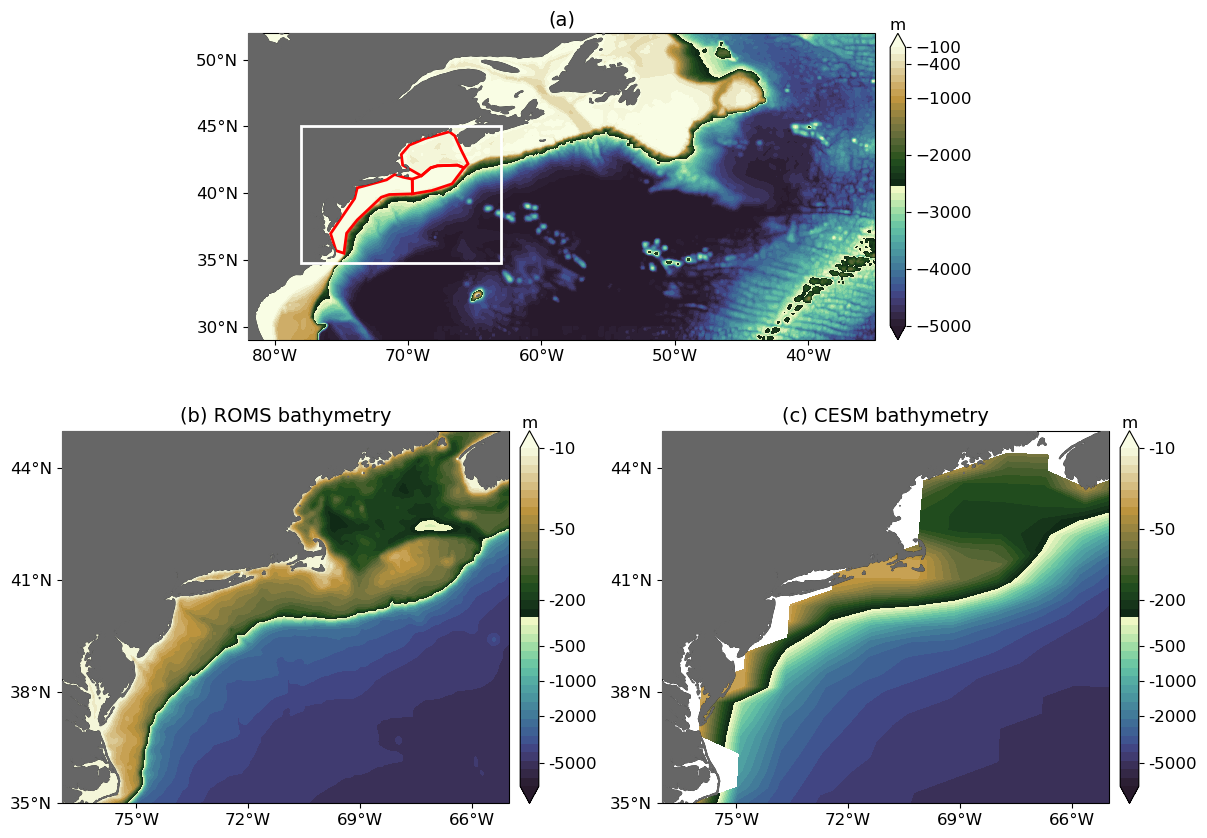

In [4]:
fig = plt.figure(figsize=(15, 10))
fs = 14
gs = gridspec.GridSpec(
    12, 12,          # 12 rows, 12 columns
    figure=fig,
    wspace=0.6,      # horizontal space between subplots
    hspace=0.6       # vertical space between subplots
)
proj = ccrs.PlateCarree(central_longitude=-180)

ax_top = fig.add_subplot(gs[0:5, 2:10], projection=proj)
cont_top = ax_top.contourf(lon_rho, lat_rho, -1*h,np.linspace(-5000, -100, 41),cmap=cm.topo, extend='both',transform=ccrs.PlateCarree())
cbar_top = fig.colorbar(cont_top, ax=ax_top, pad=0.02)
cbar_top.ax.set_title('m', fontsize=fs-2, pad=-4)
cbar_top.ax.tick_params(labelsize=fs-2)
cbar_top.set_ticks([-100, -400, -1000, -2000, -3000, -4000, -5000])
ax_top.coastlines()
ax_top.add_feature(cartopy.feature.LAND, zorder=100, color=[0.4, 0.4, 0.4])
ax_top.set_xticks(np.arange(280, 330, 10), crs=ccrs.PlateCarree())
ax_top.set_yticks(np.arange(30, 55, 5),  crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
ax_top.xaxis.set_major_formatter(lon_formatter)
ax_top.yaxis.set_major_formatter(lat_formatter)
ax_top.xaxis.set_tick_params(labelsize=fs-2)
ax_top.yaxis.set_tick_params(labelsize=fs-2)

for r in ['GOM','MAB','GB']:
    polygon_outline = patches.Polygon(vars()[r+'_coords'],closed=True, edgecolor='r', linewidth=2, facecolor='none',transform = ccrs.PlateCarree())
    ax_top.add_patch(polygon_outline);
polygon_outline = patches.Polygon(analysis_coords,closed=True, edgecolor='w', linewidth=2, facecolor='none',transform = ccrs.PlateCarree(),zorder=200)
ax_top.add_patch(polygon_outline);
ax_top.set_title('(a)', fontsize=fs)


ax_left = fig.add_subplot(gs[6:12, 0:6], projection=proj)
cont_left = ax_left.contourf(
    lon_rho, lat_rho, -1*np.log10(h),
    np.linspace(-3.9, -1, 41),
    cmap=cm.topo, extend='both',
    transform=ccrs.PlateCarree()
)
cbar_left = fig.colorbar(cont_left, ax=ax_left, pad=0.02)
cbar_left.ax.set_title('m', fontsize=fs-2, pad=-4)
cbar_left.ax.tick_params(labelsize=fs-2)
ticklabels = [-10,-50,-200,-500,-1000,-2000,-5000]
ticks = -1*np.log10([10,50,200,500,1000,2000,5000])
cbar_left.set_ticks(ticks)
cbar_left.set_ticklabels(ticklabels)
ax_left.coastlines()
ax_left.add_feature(cartopy.feature.LAND, zorder=100, color=[0.4, 0.4, 0.4])
ax_left.set_title('(b) ROMS bathymetry', fontsize=fs)
ax_left.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
ax_left.xaxis.set_major_formatter(lon_formatter); ax_left.xaxis.set_tick_params(labelsize=fs-2);
ax_left.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
ax_left.yaxis.set_major_formatter(lat_formatter); ax_left.yaxis.set_tick_params(labelsize=fs-2);
ax_left.set_extent([-77,-65,35,45], crs=ccrs.PlateCarree())


ax_right = fig.add_subplot(gs[6:12, 6:12], projection=proj)
cont_right = ax_right.contourf(
    lon_cesm, lat_cesm, -1*np.log10(ht),
    np.linspace(-3.9, -1, 41),
    cmap=cm.topo, extend='both',
    transform=ccrs.PlateCarree()
)
cbar_right = fig.colorbar(cont_right, ax=ax_right, pad=0.02)
cbar_right.ax.set_title('m', fontsize=fs-2, pad=-4)
cbar_right.ax.tick_params(labelsize=fs-2)
cbar_right.set_ticks(ticks)
cbar_right.set_ticklabels(ticklabels)
ax_right.coastlines()
ax_right.add_feature(cartopy.feature.LAND, zorder=100, color=[0.4, 0.4, 0.4])
ax_right.set_title('(c) CESM bathymetry', fontsize=fs);
ax_right.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
ax_right.xaxis.set_major_formatter(lon_formatter); ax_right.xaxis.set_tick_params(labelsize=fs-2);
ax_right.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
ax_right.yaxis.set_major_formatter(lat_formatter); ax_right.yaxis.set_tick_params(labelsize=fs-2);
ax_right.set_extent([-77,-65,35,45], crs=ccrs.PlateCarree())


<font size=5> Figure 2 Time-Mean Spatial Comparison

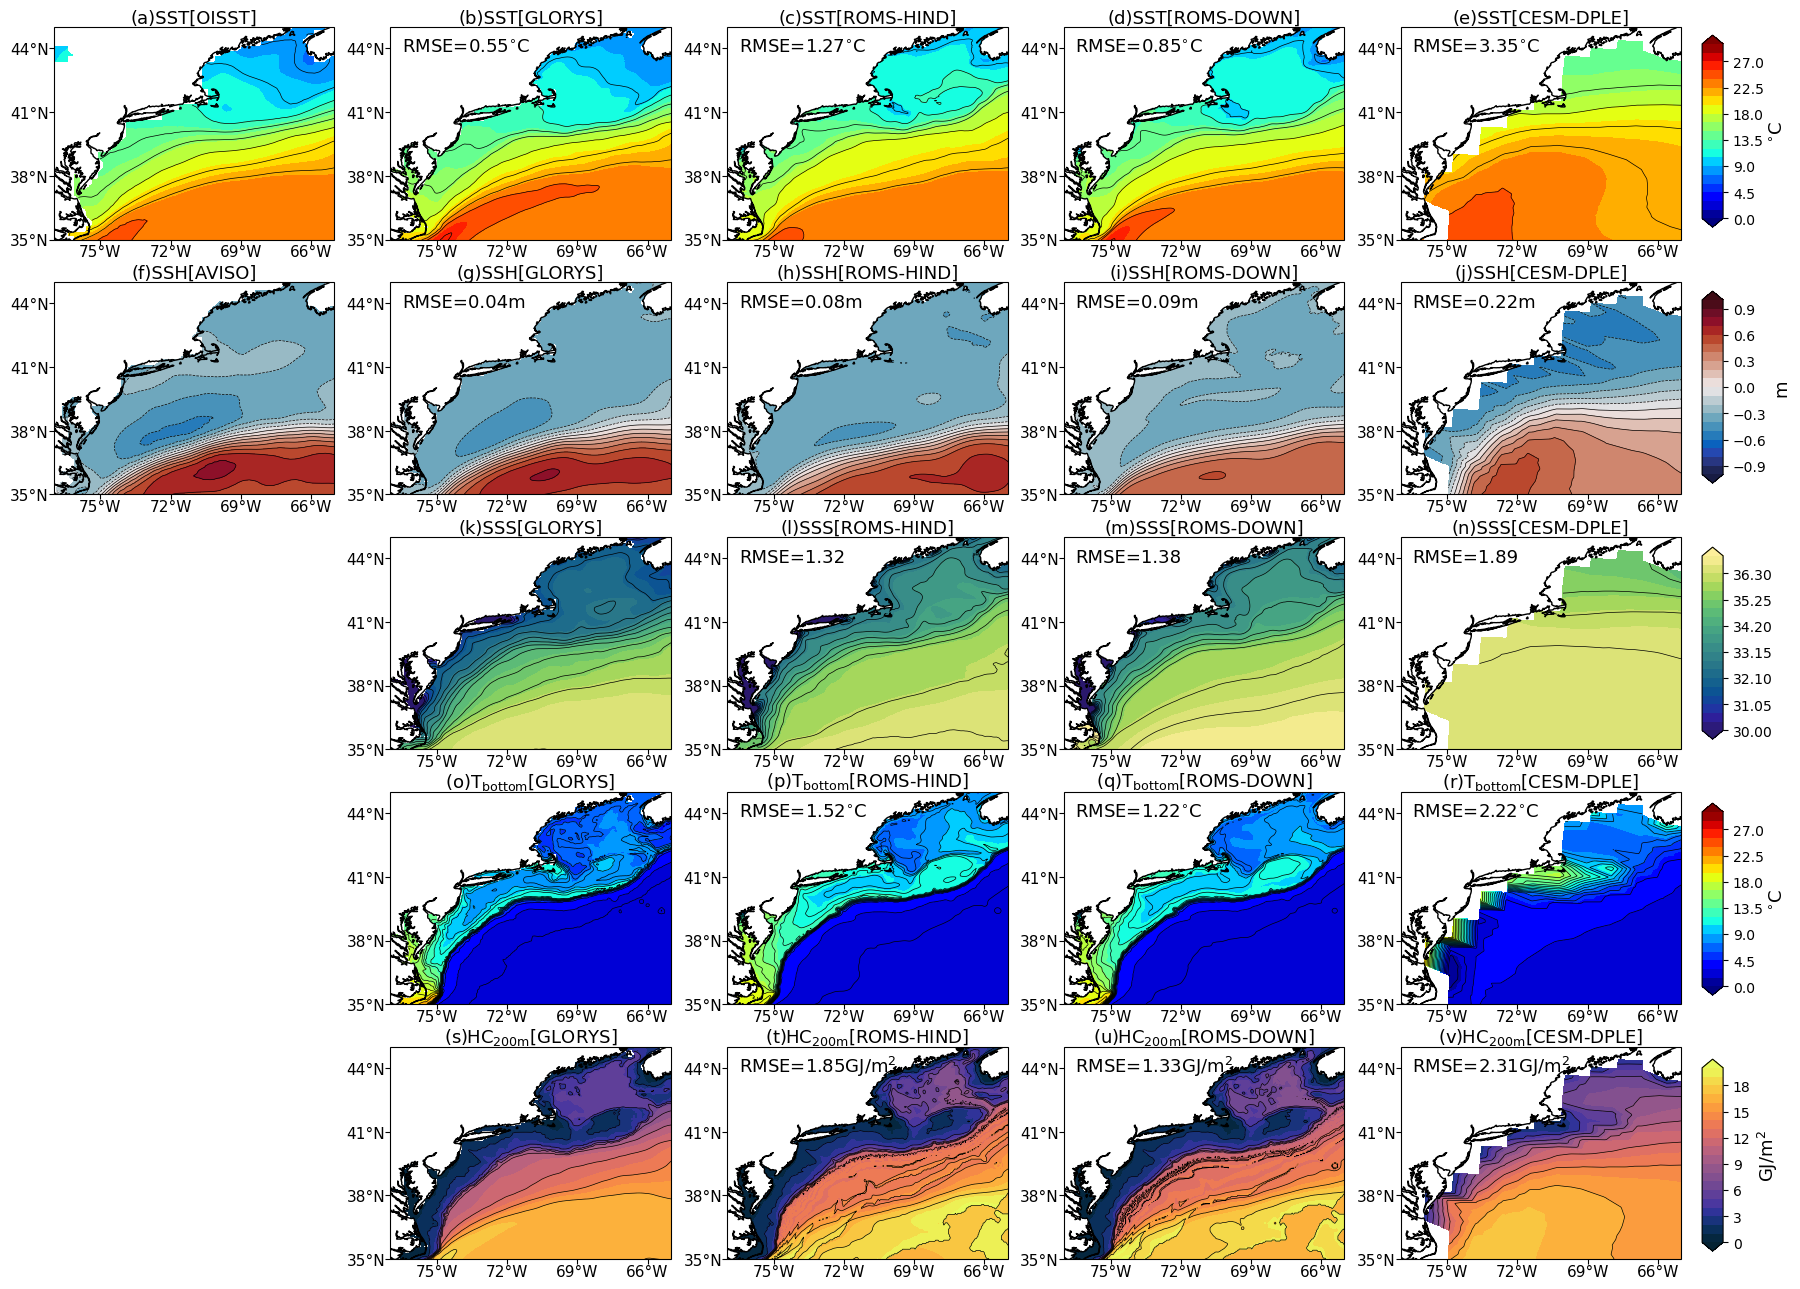

In [5]:
####Figure 1. mean distribution comparison
hindcast_years = np.arange(2004,2010,1);
nyears = hindcast_years.size
obs_years = np.arange(1993,2020,1);
Start_year = hindcast_years[0]; 
sy = Start_year-Start_years[0];
iyr_obs = int(Start_year-obs_years[0]);
jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600; ########for smaller region

variables = ['sst','ssh','sss','bottomT','Heat200']
sources = ['glorys','roms','dple40','hind']

for v,varia in enumerate(variables):
    if varia in ['sst']:
        dataset = nc.Dataset('/proj/nes/post_processed/Model_validation_monthly_series_SST_SY1992_SY2011.nc')  
        sst_obs_mean = np.mean(dataset.variables['sst_oisst'][iyr_obs*12:(iyr_obs+nyears)*12,:,:],axis=0)
        dataset.close();
    elif varia in ['ssh']:
        dataset = nc.Dataset('/proj/nes/post_processed/Model_validation_monthly_series_SSH_SY1992_SY2011.nc')  
        ssh_obs_mean = np.mean(dataset.variables['ssh_aviso'][iyr_obs*12:(iyr_obs+nyears)*12,:,:],axis=0)
        ssh_obs_mean[np.where(abs(ssh_obs_mean)>1e2)] = np.nan;
        dataset.close();
    for s,sour in enumerate(sources):
        if sour in ['hind']:
            dataset = nc.Dataset('/proj/nes/post_processed/ROMS_HINDCAST_monthly_data_2004_2009.nc','r')
            vars()[varia+'_'+sour+'_mean'] = np.mean(dataset.variables[varia+'_'+sour][:,jroms1:jroms2,iroms1:iroms2],axis=0)
            dataset.close();
        else:
            dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
            vars()[varia+'_'+sour+'_mean'] = np.mean(dataset.variables[varia+'_'+sour][sy,0:nyears,jroms1:jroms2,iroms1:iroms2],axis=0)
            dataset.close();
for sour in ['obs','glorys','roms','dple40','hind']:
    vars()['ssh_'+sour+'_mean'] = vars()['ssh_'+sour+'_mean']-np.nanmean(vars()['ssh_'+sour+'_mean'])
ssh_glorys_mean[np.where(abs(ssh_glorys_mean)>10)] = np.nan;

for sour in ['glorys','roms','dple40','hind']:
    vars()['Heat200_'+sour+'_mean'] = vars()['Heat200_'+sour+'_mean']/1e9

    
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

variables = ['sst','ssh','sss','bottomT','Heat200']
varia_names = ['SST','SSH','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
units = ['$^{\circ}$C','m','','$^{\circ}$C','GJ/m$^{2}$']
clevs = [np.linspace(0,30,21),np.linspace(-1,1,21),np.linspace(30,37,21),np.linspace(0,30,21),np.linspace(0,20,21)]
cmaps = ['jet',cm.balance,cm.haline,'jet',cm.thermal]
cont_levels = [np.arange(0,35,2),np.arange(-1.5,1.5,0.1),np.arange(30,38,0.5),np.arange(0,35,1),np.arange(0,20,2)]
sources = ['glorys','hind','roms','dple40']
source_names = ['GLORYS','ROMS-HIND','ROMS-DOWN','CESM-DPLE']
nrows = len(variables);
ncols = len(sources)+1;
k = 0;
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)']
colorbar_pos = [[0.91, 0.755, 0.01, 0.12],[0.91, 0.595, 0.01, 0.12],[0.91, 0.435, 0.01, 0.12],[0.91, 0.275, 0.01, 0.12],[0.91, 0.115, 0.01, 0.12]]

fig = plt.figure(figsize=(21,16)); fs=13; leap = 20; lw=1; pd=0;
for v,varia in enumerate(variables):
    if varia in ['sst','ssh']:
        m=fig.add_subplot(nrows,ncols,k+1,projection=ccrs.PlateCarree(central_longitude=-180))
        cont = m.contourf(lon_roms,lat_roms,vars()[varia+'_obs_mean'],clevs[v],cmap=cmaps[v],extend='both',transform = ccrs.PlateCarree());
        m.contour(lon_roms,lat_roms,vars()[varia+'_obs_mean'],cont_levels[v],colors='k',linewidths=lw-0.5,transform = ccrs.PlateCarree());
        m.coastlines();m.set_aspect('auto', adjustable=None)
        m.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
        m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-2,pad=pd);
        m.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
        m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-2,pad=pd);
        m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());    
        if varia=='sst':
            plt.title(labels[k]+varia_names[v]+'[OISST]',fontsize=fs,pad=pd)
        elif varia=='ssh':
            plt.title(labels[k]+varia_names[v]+'[AVISO]',fontsize=fs,pad=pd)
        k = k+1;
        for s,sour in enumerate(sources):
            rmse = np.sqrt(np.nanmean((vars()[varia+'_'+sour+'_mean']-vars()[varia+'_obs_mean'])**2))
            m=fig.add_subplot(nrows,ncols,k+1,projection=ccrs.PlateCarree(central_longitude=-180))
            cont = m.contourf(lon_roms,lat_roms,vars()[varia+'_'+sour+'_mean'],clevs[v],cmap=cmaps[v],extend='both',transform = ccrs.PlateCarree());
            m.contour(lon_roms,lat_roms,vars()[varia+'_'+sour+'_mean'],cont_levels[v],colors='k',linewidths=lw-0.5,transform = ccrs.PlateCarree());
            m.coastlines();m.set_aspect('auto', adjustable=None)
            m.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
            m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-2,pad=pd);
            m.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
            m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-2,pad=pd);
            m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());        
            plt.title(labels[k]+varia_names[v]+'['+source_names[s]+']',fontsize=fs,pad=pd)
            m.text(-76.5, 43.8, 'RMSE='+str(np.round(rmse,2))+units[v], fontsize=fs, transform=ccrs.PlateCarree())
            k = k+1;
    else:
        for s,sour in enumerate(sources):
            if varia=='Heat200':
                rmse = np.sqrt(np.nanmean((vars()[varia+'_'+sour+'_mean']-vars()[varia+'_glorys_mean'])**2))
            else:
                rmse = np.sqrt(np.nanmean((vars()[varia+'_'+sour+'_mean']-vars()[varia+'_glorys_mean'])**2))
            m=fig.add_subplot(nrows,ncols,k+1+v-1,projection=ccrs.PlateCarree(central_longitude=-180))
            cont = m.contourf(lon_roms,lat_roms,vars()[varia+'_'+sour+'_mean'],clevs[v],cmap=cmaps[v],extend='both',transform = ccrs.PlateCarree());
            m.contour(lon_roms,lat_roms,vars()[varia+'_'+sour+'_mean'],cont_levels[v],colors='k',linewidths=lw-0.5,transform = ccrs.PlateCarree());
            m.coastlines();m.set_aspect('auto', adjustable=None)
            m.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
            m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-2,pad=pd);
            m.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
            m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-2,pad=pd);
            m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree()); 
            plt.title(labels[k]+varia_names[v]+'['+source_names[s]+']',fontsize=fs,pad=pd)
            if sour!='glorys':
                m.text(-76.5, 43.8, 'RMSE='+str(np.round(rmse,2))+units[v], fontsize=fs, transform=ccrs.PlateCarree())
            k = k+1;

    cbar_ax = fig.add_axes(colorbar_pos[v])  # [left, bottom, width, height]
    cbar = fig.colorbar(cont, cax=cbar_ax, orientation='vertical')
    cbar.set_label(units[v], fontsize=fs);
    
    

<font size=5> Figure 3 Temporal RMSE comparison

In [7]:
hindcast_years = np.arange(2004,2009,1);  ####Model validation files only for 5-years
nyears = hindcast_years.size
obs_years = np.arange(1993,2020,1);
Start_year = hindcast_years[0]; 
sy = Start_year-Start_years[0];
iyr_obs = int(Start_year-obs_years[0]);
jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600; ########for smaller region

variables = ['sst','ssh','sss','bottomT','Heat200']
varia_filenames = ['SST','SSH','SSS','bottomT','Heat200']
sources = ['roms','cesm','hind']
    
for v,varia in enumerate(variables):
    dataset = nc.Dataset('/proj/nes/post_processed/Model_validation_monthly_series_'+varia_filenames[v]+'_SY1992_SY2011.nc','r')
    for s,sour in enumerate(sources):
        if varia == ['ssh']:
            data_o = dataset.variables[varia+'_glorys'][iyr_obs*12:(iyr_obs+nyears)*12,:,:]-np.mean(dataset.variables[varia+'_glorys'][iyr_obs*12:(iyr_obs+nyears)*12,:,:],axis=0);
            if sour in ['hind']:
                dataset_hind = nc.Dataset('/proj/nes/post_processed/ROMS_HINDCAST_monthly_data_2004_2009.nc','r')
                data_m = dataset_hind.variables[varia+'_'+sour][0:12*nyears,jroms1:jroms2,iroms1:iroms2]-np.mean(dataset_hind.variables[varia+'_'+sour][0:12*nyears,jroms1:jroms2,iroms1:iroms2],axis=0)
                dataset_hind.close();
            else:
                ens_mean = np.mean(dataset.variables[varia+'_'+sour][sy,:,:,:,:],axis=0)
                data_m = ens_mean-np.mean(ens_mean,axis=0)
            vars()['rmse_'+varia+'_'+sour] = np.sqrt(np.mean((data_m-data_o)**2,axis=0))            
        else:
            data_o = dataset.variables[varia+'_glorys'][iyr_obs*12:(iyr_obs+nyears)*12,:,:];
            if sour in ['hind']:
                dataset_hind = nc.Dataset('/proj/nes/post_processed/ROMS_HINDCAST_monthly_data_2004_2009.nc','r')
                data_m = dataset_hind.variables[varia+'_'+sour][0:12*nyears,jroms1:jroms2,iroms1:iroms2]
                dataset_hind.close();
            else:
                data_m = np.mean(dataset.variables[varia+'_'+sour][sy,:,:,:,:],axis=0)
            vars()['rmse_'+varia+'_'+sour] = np.sqrt(np.mean((data_m-data_o)**2,axis=0))
    dataset.close()
    
for sour in sources:
    vars()['rmse_Heat200_'+sour] = vars()['rmse_Heat200_'+sour]/1e9
    vars()['rmse_ssh_'+sour] = vars()['rmse_ssh_'+sour]*1e2
    
# rmse_ssh_glorys[np.where(rmse_ssh_glorys>1e2)] = np.nan
# rmse_ssh_roms[np.where(rmse_ssh_roms>1e2)] = np.nan
# rmse_ssh_cesm[np.where(rmse_ssh_cesm>1e2)] = np.nan


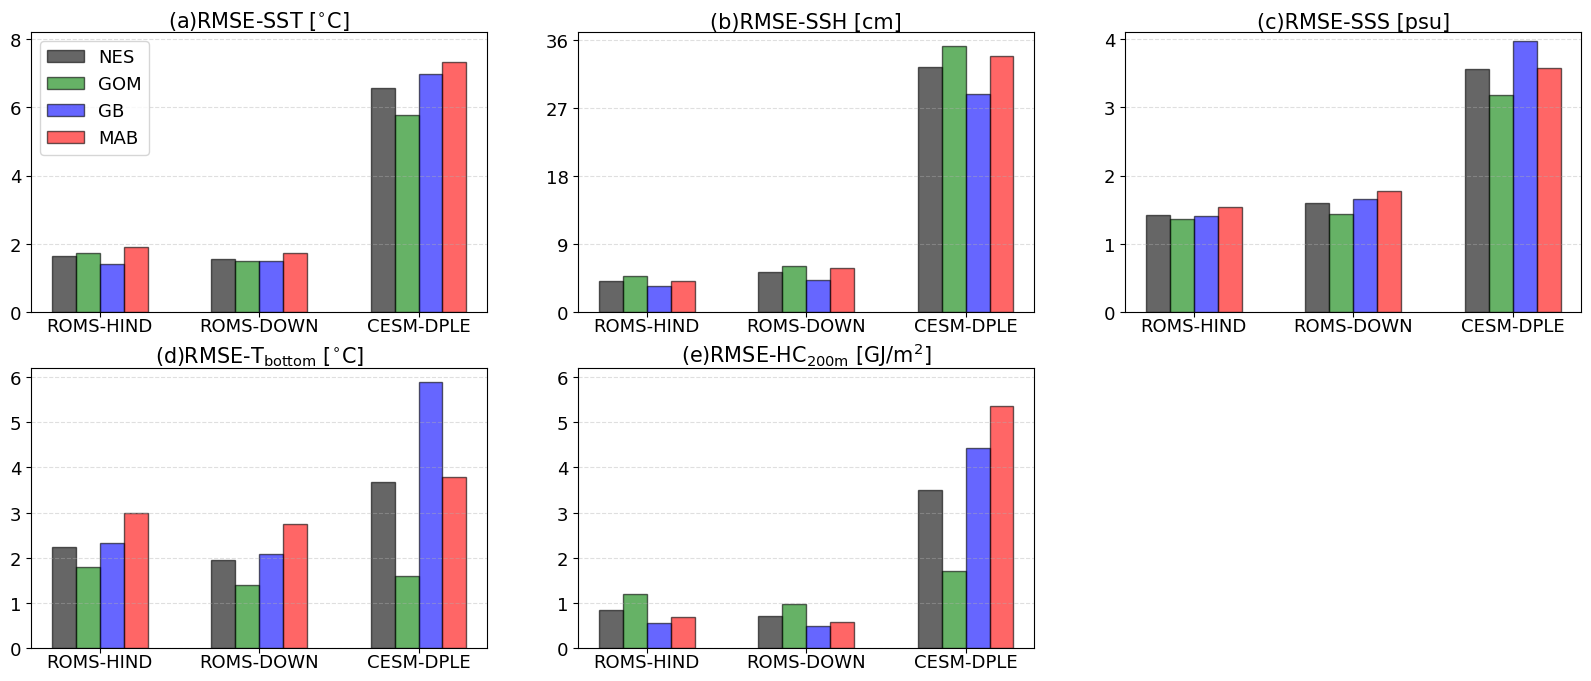

In [10]:
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

variables = ['sst','ssh','sss','bottomT','Heat200']
varia_names = ['SST','SSH','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
units = ['$^{\circ}$C','cm','psu','$^{\circ}$C','GJ/m$^{2}$']
sources = ['hind','roms','cesm']
source_names = ['ROMS-HIND','ROMS-DOWN','CESM-DPLE']
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)']
regions = ['all','GOM', 'MAB', 'GB']
region_names = ['NES', 'GOM', 'GB','MAB']
yticks = [np.arange(0,9,2),np.arange(0,37,9),np.arange(0,4.02,1),np.arange(0,7,1),np.arange(0,7,1)]
ylims = [8.2,37,4.1,6.2,6.2]
fig = plt.figure(figsize=(20,8)); fs = 13;

for v, varia in enumerate(variables):
    rmse_vals = np.zeros((len(sources), len(regions)))
    for i, sour in enumerate(sources):
        for j, region in enumerate(regions):
            rmse_vals[i, j] = np.nanmean(vars()['rmse_'+varia+'_'+sour]*vars()[region+'_mask'])

    bar_width = 0.15
    x = np.arange(len(sources))  # group positions
    region_colors = ['k','green','b','r']
    total_bar_width = bar_width * len(regions)
    offsets = np.arange(len(regions)) * bar_width - total_bar_width / 2 + bar_width / 2

    ax = fig.add_subplot(2,3,v+1)
    for j, region in enumerate(regions):
        ax.bar(x + offsets[j], rmse_vals[:, j], width=bar_width,
               label=region_names[j], color=region_colors[j],alpha=0.6, edgecolor='black')

    ax.set_xticks(x); ax.set_xticklabels(source_names, fontsize=fs);
    ax.tick_params(axis='y',labelsize=fs)  
    ax.tick_params(axis='x',labelsize=fs, pad=0)

    ax.set_ylim(0, np.nanmax(rmse_vals) + 1);
    ax.set_title(labels[v]+'RMSE-'+varia_names[v]+' ['+units[v]+']',fontsize=fs+2,pad=0)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if v==0:
        ax.legend(fontsize=fs, title_fontsize=fs);
    ax.set_yticks(yticks[v]); ax.set_ylim(0,ylims[v])
    

<font size=5> Figure 4 Time series of SST

In [15]:
#regional mean time series and decomposition
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
i1_north = 750; i2_north = 1050; j1_north = 380; j2_north = 466;
i1_south = 350; i2_south = 650; j1_south = 0; j2_south = 90;

sources = ['glorys','roms','dple40','lens'];
variables = ['sst']#,'sss'];
varia_names = ['SST']#,'SSS']
types = [''] #,'_detrended','_highpassed']#,'_nolens40'];
regions = ['all']

for v,varia in enumerate(variables):
    for j, sour in enumerate(sources):
        for i, region in enumerate(regions):
            for t, ty in enumerate(types):
                vars()[varia+'_anomaly_'+sour+'_'+region+ty] = np.zeros((len(Start_years),len(FY)));
            for fy in FY:
                dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc');
                if region in ['north','south']:
                    j1=vars()['j1_'+region]; j2 = vars()['j2_'+region];
                    i1=vars()['i1_'+region]; i2 = vars()['i2_'+region];
                    data0 = np.nanmean(dataset.variables[varia+'_'+sour+'_anomaly'][:,fy-1,j1:j2,i1:i2],axis=(1,2))
                else:
                    data0 = np.nanmean(dataset.variables[varia+'_'+sour+'_anomaly'][:,fy-1,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,:,:],axis=(1,2))
                dataset.close();
                ####raw series
                vars()[varia+'_anomaly_'+sour+'_'+region][:,fy-1] = data0
#                 ####detrended series
#                 vars()[varia+'_anomaly_'+sour+'_'+region+'_detrended'][:,fy-1] = detrend_series(data0);
#                 ####high-passed series
#                 vars()[varia+'_anomaly_'+sour+'_'+region+'_highpassed'][:,fy-1] = data0-lowpass_filter_1d(data0, cutoff_years=10, fs=1.0)


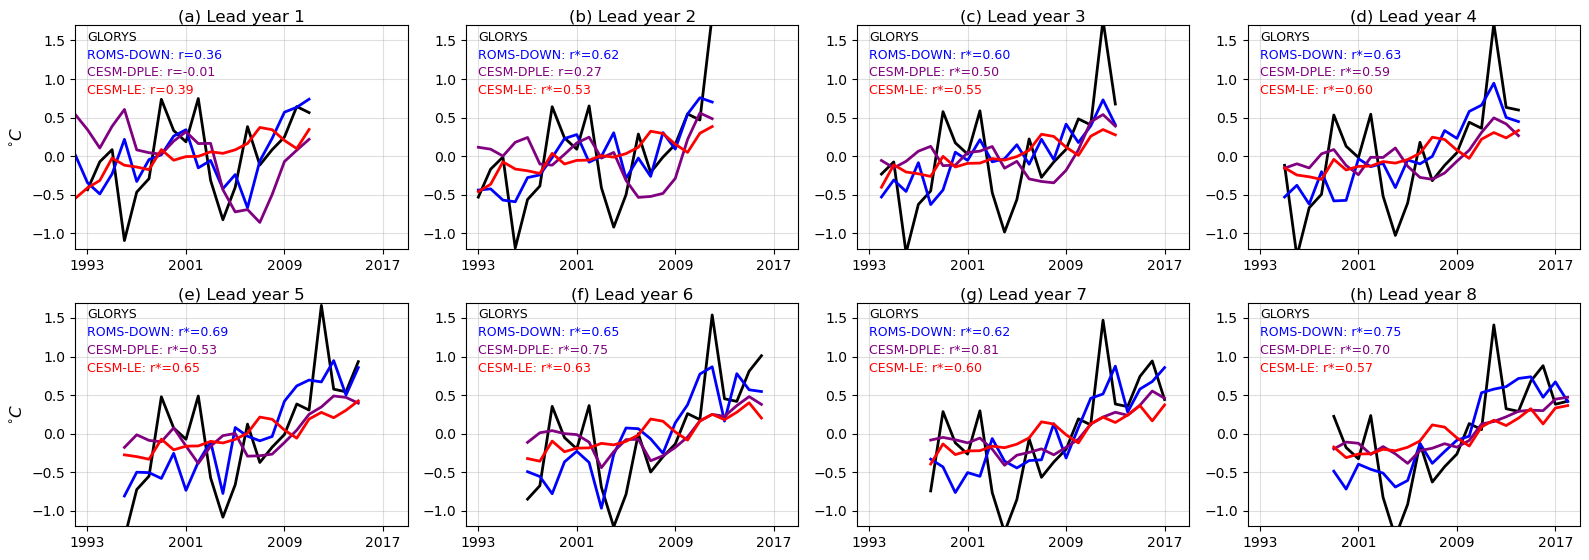

In [16]:
sources = ['glorys','roms','dple40','lens'];
variables = ['sst']#,'ssh','sss','bottomT','Heat200'];
varia_names = ['SST']#,'SSH','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
units = ['$^{\circ}C$']#,'m','','$^{\circ}C$','GJ/m$^2$']
types = ['']#,'_detrended','_highpassed']#,'_nolens40'];
type_names = ['']#,'w/o trend','w/o low-freq']
regions = ['all']#, 'GOM', 'GB','MAB']
region_names = ['NES']#, 'GOM', 'GB','MAB']
colors = ['black','blue','purple','red']
line_labels = ['GLORYS','ROMS-DOWN','CESM-DPLE','CESM-LE']
fs = 12; lw = 2;
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)','(w)','(x)','(y)','(z)']

text_x = 1993  # year (x-axis) where the text will be placed
ylim1 = [-1.2,-0.05,-0.98,-1.5,-8e8];
ylim2 = [1.7,0.05,0.98,1.5,8e8];
for v, varia in enumerate(variables):
    y_min = ylim1[v]; y_max = ylim2[v]; y_range = y_max - y_min;
    text_y_start = y_max - 0.07 * y_range   # 5% below the top
    text_y_gap = 0.08 * y_range             # 8% vertical gap
    for i, region in enumerate(regions):
        for t, ty in enumerate(types):
            fig, axs = plt.subplots(2, 4, figsize=(16, 6))
            axs = axs.flatten()
            for fy in FY:
                ax = axs[fy - 1]
                xyear = Start_years + fy - 1
                y_text = text_y_start
                for j, sour in enumerate(sources):
                    data = vars()[varia + '_anomaly_' + sour + '_' + region + ty][:, fy - 1]
                    ax.plot(xyear, data, color=colors[j], linewidth=lw)
                    if sour in ['roms', 'dple40', 'lens']:
                        data0 = vars()[varia + '_anomaly_glorys_' + region + ty][:, fy - 1]
                        mask = ~np.isnan(data) & ~np.isnan(data0)
                        r_val, p_val = pearsonr(data[mask], data0[mask])
#                         p_str = "p<0.05" if p_val < 0.05 else "p>0.05"
#                         label_str = f"{line_labels[j]}: r={r_val:.2f}, {p_str}"
                        r_label = f"r*={r_val:.2f}" if p_val < 0.05 else f"r={r_val:.2f}"
                        p_str = "p<0.05" if p_val < 0.05 else "p>0.05"
                        label_str = f"{line_labels[j]}: {r_label}" #, {p_str}"

                        ax.text(text_x, y_text, label_str,color=colors[j], fontsize=fs-3, transform=ax.transData)
                        y_text -= text_y_gap
                    elif sour == 'glorys':
                        label_str = f"{line_labels[j]}"
                        ax.text(text_x, y_text, label_str,color=colors[j], fontsize=fs-3, transform=ax.transData)
                        y_text -= text_y_gap

                ax.set_xticks(np.arange(1993, 2020, 8))
                ax.set_xlim(1992, 2019)
                ax.set_ylim(ylim1[v],ylim2[v])  # adjust if needed
                ax.grid(True, alpha=0.4)
                ax.set_title(labels[fy-1]+' Lead year '+str(fy), pad=1, fontsize=fs)
                if fy in [1,5]:
                    ax.set_ylabel(units[v],fontsize=fs)
            title = f"{varia_names[v]} {type_names[t]} [{region_names[i]}]" if t > 0 else f"{varia_names[v]} [{region_names[i]}]"
            #fig.suptitle(title,y=0.92, fontsize=fs+2)
            fig.tight_layout(rect=[0, 0, 1, 0.95])            


<font size=5> Figure 5 ACC of SST maps

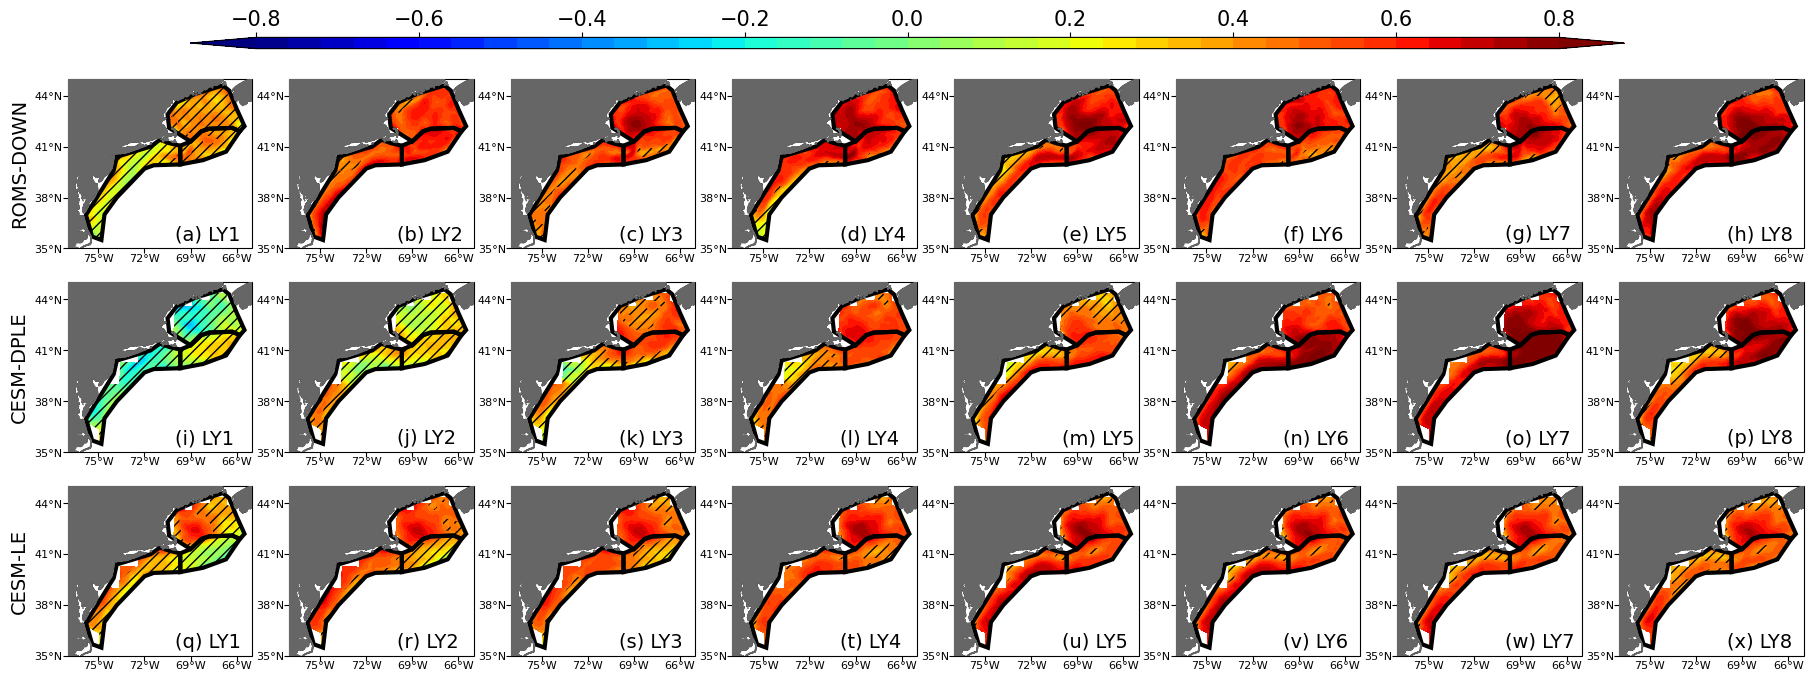

In [17]:
#####Shelf only ACC maps
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
sources = ['roms','dple40','lens'];
names = ['ROMS-DOWN','CESM-DPLE','CESM-LE']
variables = ['sst']#,'ssh','sss','bottomT','Heat200'];
varia_names = ['SST']#,'SSH','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
types = ['']#,'_detrended','_highpassed','_nolens40'];
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)','(w)','(x)','(y)','(z)']

skip_sour_ty_combinations = {('lens', '_nolens40'), ('lens40', '_nolens40')}

nrows = len(sources); ncols = len(FY);
subplot_width = 2.8; subplot_height = 2.5;
figsize = (ncols * subplot_width, nrows * subplot_height)

for v,varia in enumerate(variables):
    for ty in types:
        fig = plt.figure(figsize=figsize); fs=10; leap = 20; lw=1; kk=0;
        for i, sour in enumerate(sources):
            if (sour,ty) in skip_sour_ty_combinations:
                continue
            else:
                for j,tau in enumerate(FY):
                    k = i*ncols+j;
                    dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_ACC_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
                    acc = dataset.variables['acc_'+varia+'_'+sour+ty][tau-1,jroms1:jroms2,iroms1:iroms2]
                    pacc = dataset.variables['pacc_'+varia+'_'+sour+ty][tau-1,jroms1:jroms2,iroms1:iroms2]
                    lon_roms = dataset.variables['lon_roms'][jroms1:jroms2,iroms1:iroms2]
                    lat_roms = dataset.variables['lat_roms'][jroms1:jroms2,iroms1:iroms2]
                    dataset.close();
                    m=fig.add_subplot(nrows,ncols,k+1,projection=ccrs.PlateCarree(central_longitude=-180))
                    cont = m.contourf(lon_roms,lat_roms,acc*all_mask,np.linspace(-0.8,0.8,41),cmap='jet',extend='both',transform = ccrs.PlateCarree());
                    #cont = m.contourf(lon_roms,lat_roms,acc*all_mask,np.linspace(-1,1,21),cmap='seismic',extend='both',transform = ccrs.PlateCarree());
                    condition = (pacc >= 0.05) & (~np.isnan(all_mask))  # p < 0.05
                    hatch_contour = m.contourf(lon_roms,lat_roms, condition, colors='none', levels=[0.5,1.5],hatches=['///'], transform=ccrs.PlateCarree())
                    m.coastlines();m.set_aspect('auto', adjustable=None)
                    m.add_feature(cartopy.feature.LAND,zorder=100,color=[0.4,0.4,0.4])
                    m.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
                    m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-2,pad=0);
                    m.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
                    m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-2,pad=0);
                    m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());                        
                    for r in ['GOM','MAB','GB']:#['all','SMAB','NMAB','WGOM','EGOM','GB']:
                        polygon_outline = patches.Polygon(vars()[r+'_coords'],closed=True, edgecolor='k', linewidth=3, facecolor='none',transform = ccrs.PlateCarree())
                        m.add_patch(polygon_outline);
                    #plt.title(labels[kk]+names[i]+'; LY'+str(tau),fontsize=fs,pad=0)
                    m.text(-70,35.5,labels[kk]+' LY'+str(tau),fontsize=fs+4,color='k',zorder=200, transform=ccrs.PlateCarree())
                    kk += 1;
                    if kk in [1,9,17]:
                        m.set_ylabel(names[i],fontsize=fs+4)
        cbar_ax = fig.add_axes([0.18, 0.92, 0.64, 0.015])  # [left, bottom, width, height]
        cbar = fig.colorbar(cont, cax=cbar_ax, orientation='horizontal')
        cbar.ax.xaxis.set_ticks_position('top'); cbar.ax.xaxis.set_label_position('top');
        cbar.ax.tick_params(labelsize=fs + 5, pad=2);

        

<font size =5>Figure 6 Regional mean ACC of SST

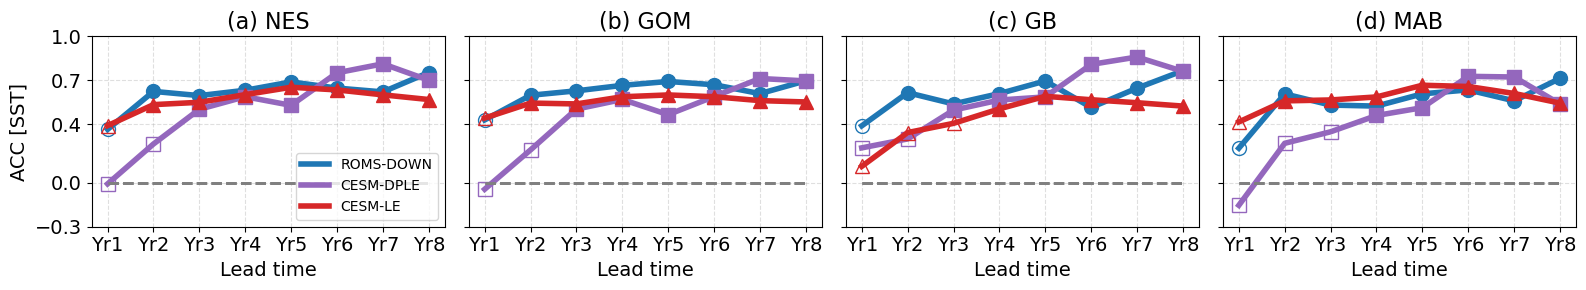

In [27]:
####Regional mean ACC (calculate mean series first and then calculate acc)
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
sources = ['roms','dple40','lens'];
variables = ['sst']#,'ssh','sss','bottomT','Heat200'];
types = ['']#,'_detrended','_highpassed','_nolens40'];
regions = ['all', 'GOM', 'GB','MAB']
names = ['(a) NES', '(b) GOM', '(c) GB','(d) MAB']

for varia in variables:
    for sour in sources:
        dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
        for i,region in enumerate(regions):
            data1 = np.nanmean(dataset.variables[varia+'_glorys'][:,:,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,None,:,:],axis=(2,3))
            data2 = np.nanmean(dataset.variables[varia+'_'+sour][:,:,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,None,:,:],axis=(2,3))
            data_lens40 = np.nanmean(dataset.variables[varia+'_lens40'][:,:,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,None,:,:],axis=(2,3))
            
            for ty in types:
                vars()['mean_acc_'+varia+'_'+sour+'_'+region+ty] = np.zeros(len(FY));
                vars()['mean_pacc_'+varia+'_'+sour+'_'+region+ty] = np.zeros(len(FY));
            for fy in FY:
                series1 = data1[:,fy-1]-np.nanmean(data1[:,fy-1]); series2 = data2[:,fy-1]-np.nanmean(data2[:,fy-1]);
                ####raw acc
                vars()['mean_acc_'+varia+'_'+sour+'_'+region][fy-1],vars()['mean_pacc_'+varia+'_'+sour+'_'+region][fy-1] = calculate_acc(series1,series2);
#                 ###acc for series without linear trend
#                 series1_linear = detrend_series(series1);
#                 series2_linear = detrend_series(series2);
#                 vars()['mean_acc_'+varia+'_'+sour+'_'+region+'_detrended'][fy-1],vars()['mean_pacc_'+varia+'_'+sour+'_'+region+'_detrended'][fy-1] = calculate_acc(series1_linear,series2_linear);
#                 ###acc for series without linear trend or low-frequency variation (10 year here)
#                 vars()['mean_acc_'+varia+'_'+sour+'_'+region+'_highpassed'][fy-1],vars()['mean_pacc_'+varia+'_'+sour+'_'+region+'_highpassed'][fy-1] = acc_high_freq_1d(series1_linear,series2_linear,cutoff_years=10);
#                 ###acc for series without lens40
#                 if sour in ['roms','dple40']:
#                     series_lens40 = data_lens40[:,fy-1]-np.nanmean(data_lens40[:,fy-1]);
#                     vars()['mean_acc_'+varia+'_'+sour+'_'+region+'_nolens40'][fy-1],vars()['mean_pacc_'+varia+'_'+sour+'_'+region+'_nolens40'][fy-1] = calculate_acc(series1-series_lens40,series2-series_lens40);


####Regional mean plot
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
sources = ['roms','dple40','lens'];
variables = ['sst']#,'ssh','sss','bottomT','Heat200'];
varia_names = ['SST']#,'SSH','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
types = ['']#,'_detrended','_highpassed']#,'_nolens40'];
regions = ['all', 'GOM', 'GB','MAB']
names = ['(a) NES', '(b) GOM', '(c) GB','(d) MAB']

skip_sour_ty_combinations = {('lens', '_nolens40'), ('lens40', '_nolens40')}

nrows = len(types); ncols = len(regions);
subplot_width = 2; subplot_height = 2.;
figsize = (ncols * subplot_width, nrows * subplot_height)
lead_years = np.arange(1, 9);
linestyles = ['-o', '-s', '-^', '-v', '-d', '-*']
colors = ['tab:blue','tab:purple','tab:red', 'tab:orange', 'tab:green',  'tab:brown']
labels = ['ROMS-DOWN','CESM-DPLE','CESM-LE']
fs = 14; lw = 4; ms=10;
all_acc_min = np.inf
all_acc_max = -np.inf

for v,varia in enumerate(variables):
    for t, ty in enumerate(types):
        nrows = 1; ncols = len(regions);
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
        axes = np.atleast_2d(axes)  # ensures axes[t, i] works
        for i, region in enumerate(regions):
            ax = axes[0, i]
            for j, sour in enumerate(sources):
                if (sour, ty) in skip_sour_ty_combinations:
                    continue
                acc = vars()['mean_acc_'+varia+'_'+sour+'_'+region+ty]
                pacc = vars()['mean_pacc_'+varia+'_'+sour+'_'+region+ty]
                ax.plot(lead_years, acc, linestyle=linestyles[j][:-1], color=colors[j],label=labels[j],linewidth=lw)
                ax.plot(lead_years, np.zeros(lead_years.size), linestyle='--', color='grey',linewidth=lw-2)
                # Step 2: plot markers based on significance
                for k, (x, y, p) in enumerate(zip(lead_years, acc, pacc)):
                    markerface = colors[j] if p < 0.05 else 'none'
                    ax.plot(x, y, marker=linestyles[j][-1], linestyle='none',
                            markeredgecolor=colors[j], markerfacecolor=markerface,
                            markersize=ms, linewidth=lw)
                    
                acc_min = np.nanmin(acc)
                acc_max = np.nanmax(acc)
                if acc_min < all_acc_min:
                    all_acc_min = acc_min
                if acc_max > all_acc_max:
                    all_acc_max = acc_max

            ax.set_xticks(lead_years)
            ax.set_xticklabels([f'Yr{y}' for y in lead_years], fontsize=fs)
            ax.set_xlabel('Lead time', fontsize=fs)
            ax.set_title(names[i], fontsize=fs+2)
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.tick_params(axis='y', labelsize=fs)
            ax.tick_params(axis='x', labelsize=fs)
            
            margin = 0.05
            ymin = np.floor((all_acc_min - margin) * 10) / 10
            ymax = np.ceil((all_acc_max + margin) * 10) / 10
            yticks = np.linspace(ymin, ymax, num=5)
            yticks = np.round(yticks, 1)  # round to 1 decimal
            ax.set_yticks(yticks)
            ax.set_ylim(yticks[0], yticks[-1])

            if i == 0:
                ax.set_ylabel('ACC ['+varia_names[v]+']', fontsize=fs)
                ax.legend(loc='lower right', fontsize=fs-4)

        plt.tight_layout()


<font size=5> Figure 7 Brier Score of SST

In [29]:
jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;

variables = ['sst']#,'ssh','sss','bottomT','Heat200']
varia_names = ['SST']#,'SSH','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
metrics = ['brier_score']#,'decomp_brier','decomp_reliability','decomp_resolution','decomp_uncertainty']
metric_names = ['Brier_score','BrS','BrS Reliability','BrS Resolution','BrS Uncertainty']
events = ['upper','lower']
event_names = ['Upper Tercile','Lower Tercile']
regions = ['all', 'GOM', 'GB','MAB']
region_names = ['NES', 'GOM', 'GB','MAB']

dataset = nc.Dataset('/proj/nes/post_processed/Brier_Score_ROMS_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
lon_roms = dataset.variables['lon_roms'][jroms1:jroms2,iroms1:iroms2]
lat_roms = dataset.variables['lat_roms'][jroms1:jroms2,iroms1:iroms2]
dataset.close();

for varia in variables:
    for met in metrics:
        for evt in events:
             dataset = nc.Dataset('/proj/nes/post_processed/Brier_Score_ROMS_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
             vars()[varia+'_'+evt+'_'+met+'_roms'] = dataset.variables[varia+'_'+evt+'_'+met][:,:,jroms1:jroms2,iroms1:iroms2]
             dataset.close();

for varia in variables:
    for met in metrics:
        for evt in events:
             for reg in regions:
                 vars()[varia+'_'+evt+'_'+met+'_'+reg+'_roms'] = np.nanmean(vars()[varia+'_'+evt+'_'+met+'_roms']*vars()[reg+'_mask'],axis=(2,3))

for varia in variables:
    for met in metrics:
        for evt in events:
             dataset = nc.Dataset('/proj/nes/post_processed/Brier_Score_DPLE40_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
             vars()[varia+'_'+evt+'_'+met+'_dple'] = dataset.variables[varia+'_'+evt+'_'+met][:,:,jroms1:jroms2,iroms1:iroms2]
             dataset.close();

for varia in variables:
    for met in metrics:
        for evt in events:
             for reg in regions:
                 vars()[varia+'_'+evt+'_'+met+'_'+reg+'_dple'] = np.nanmean(vars()[varia+'_'+evt+'_'+met+'_dple']*vars()[reg+'_mask'],axis=(2,3))


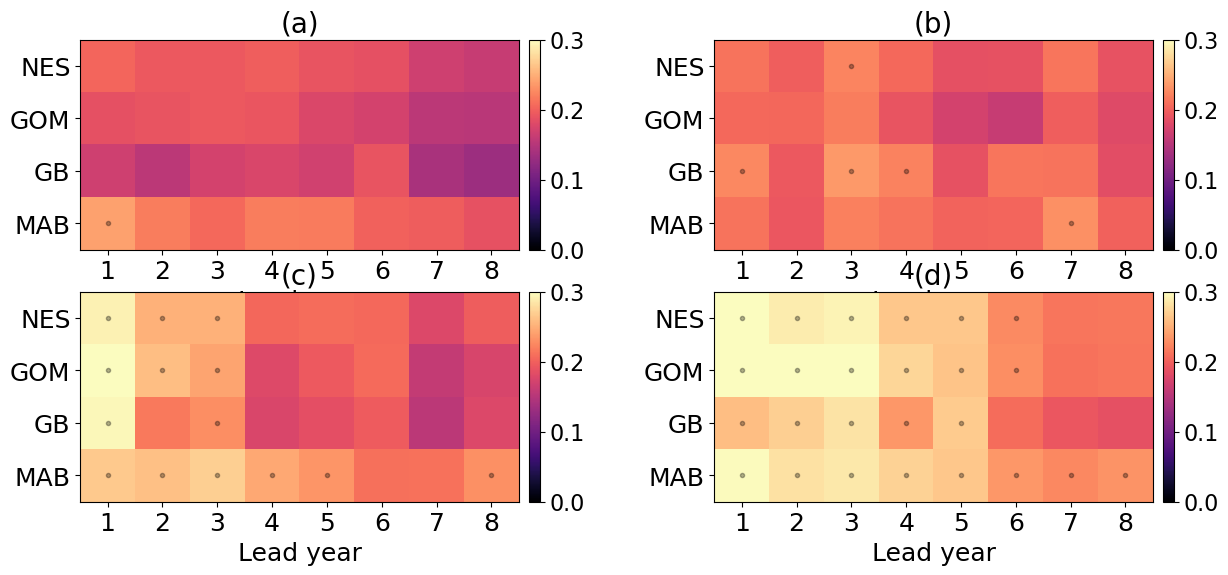

In [33]:
bs_ref = 2/9

varia = 'sst'
metric = 'brier_score'

events = ['upper', 'lower']
models = ['roms', 'dple']

regions = ['all', 'GOM', 'GB', 'MAB']
region_names = ['NES', 'GOM', 'GB', 'MAB']

lead_years = np.arange(1, 9)

labels = ['(a)', '(b)', '(c)', '(d)']

fs = 18
min0 = 0
max0 = 0.3
cmap0 = 'magma'

fig, axes = plt.subplots(2, 2, figsize=(15, 6))
axes = axes.flatten()

panel = 0

for r, model in enumerate(models):
    for c, evt in enumerate(events):
        ax = axes[panel]
        data = np.zeros((len(regions), len(lead_years)))
        for i, reg in enumerate(regions):
            data[i, :] = np.mean(vars()[f'{varia}_{evt}_{metric}_{reg}_{model}'],axis=0)

        im = ax.imshow(data,vmin=min0,vmax=max0,cmap=cmap0,aspect='auto')

        noskill_mask = data >= bs_ref
        y, x = np.where(noskill_mask)
        ax.plot(x, y, 'k.', markersize=6, alpha=0.3)

        ax.set_xticks(np.arange(len(lead_years)))
        ax.set_xticklabels(lead_years, fontsize=fs)
        ax.set_yticks(np.arange(len(regions)))
        ax.set_yticklabels(region_names, fontsize=fs)
        ax.set_xlabel('Lead year', fontsize=fs)
        ax.set_title(labels[panel], fontsize=fs+2, loc='center')

        cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
        cbar.ax.tick_params(labelsize=fs-2)

        panel += 1


<font size=5> Figure 8 Skill Difference Between ROMS-DOWN and CESM-DPLE

In [43]:
####acc difference between dple and roms
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
sources = ['roms','dple40','lens'];
variables = ['sst','sss','bottomT','Heat200'];
types = ['']#,'_detrended','_highpassed','_nolens40'];
regions = ['all', 'GOM', 'GB','MAB']
names = ['(a) NES', '(b) GOM', '(c) GB','(d) MAB']

for varia in variables:
    for sour in sources:
        dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
        for i,region in enumerate(regions):
            data1 = np.nanmean(dataset.variables[varia+'_glorys'][:,:,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,None,:,:],axis=(2,3))
            data2 = np.nanmean(dataset.variables[varia+'_'+sour][:,:,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,None,:,:],axis=(2,3))
            data_lens40 = np.nanmean(dataset.variables[varia+'_lens40'][:,:,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,None,:,:],axis=(2,3))
            
            for ty in types:
                vars()['mean_acc_'+varia+'_'+sour+'_'+region+ty] = np.zeros(len(FY));
                vars()['mean_pacc_'+varia+'_'+sour+'_'+region+ty] = np.zeros(len(FY));
            for fy in FY:
                series1 = data1[:,fy-1]-np.nanmean(data1[:,fy-1]); series2 = data2[:,fy-1]-np.nanmean(data2[:,fy-1]);
                ####raw acc
                vars()['mean_acc_'+varia+'_'+sour+'_'+region][fy-1],vars()['mean_pacc_'+varia+'_'+sour+'_'+region][fy-1] = calculate_acc(series1,series2);

                
####brier score difference
variables = ['sst','sss','bottomT','Heat200']
varia_names = ['SST','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
metrics = ['brier_score']#,'decomp_brier','decomp_reliability','decomp_resolution','decomp_uncertainty']
metric_names = ['Brier_score']#,'BrS','BrS Reliability','BrS Resolution','BrS Uncertainty']
events = ['upper','lower']
event_names = ['Upper Tercile','Lower Tercile']
regions = ['all', 'GOM', 'GB','MAB']
region_names = ['NES', 'GOM', 'GB','MAB']

dataset = nc.Dataset('/proj/nes/post_processed/Brier_Score_ROMS_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
lon_roms = dataset.variables['lon_roms'][jroms1:jroms2,iroms1:iroms2]
lat_roms = dataset.variables['lat_roms'][jroms1:jroms2,iroms1:iroms2]
dataset.close();

for varia in variables:
    for met in metrics:
        for evt in events:
             dataset = nc.Dataset('/proj/nes/post_processed/Brier_Score_ROMS_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
             vars()[varia+'_'+evt+'_'+met+'_roms'] = dataset.variables[varia+'_'+evt+'_'+met][:,:,jroms1:jroms2,iroms1:iroms2]
             dataset.close();

for varia in variables:
    for met in metrics:
        for evt in events:
             for reg in regions:
                 vars()[varia+'_'+evt+'_'+met+'_'+reg+'_roms'] = np.nanmean(vars()[varia+'_'+evt+'_'+met+'_roms']*vars()[reg+'_mask'],axis=(2,3))

for varia in variables:
    for met in metrics:
        for evt in events:
             dataset = nc.Dataset('/proj/nes/post_processed/Brier_Score_DPLE40_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
             vars()[varia+'_'+evt+'_'+met+'_dple'] = dataset.variables[varia+'_'+evt+'_'+met][:,:,jroms1:jroms2,iroms1:iroms2]
             dataset.close();

for varia in variables:
    for met in metrics:
        for evt in events:
             for reg in regions:
                 vars()[varia+'_'+evt+'_'+met+'_'+reg+'_dple'] = np.nanmean(vars()[varia+'_'+evt+'_'+met+'_dple']*vars()[reg+'_mask'],axis=(2,3))
    
bs_ref = 2/9


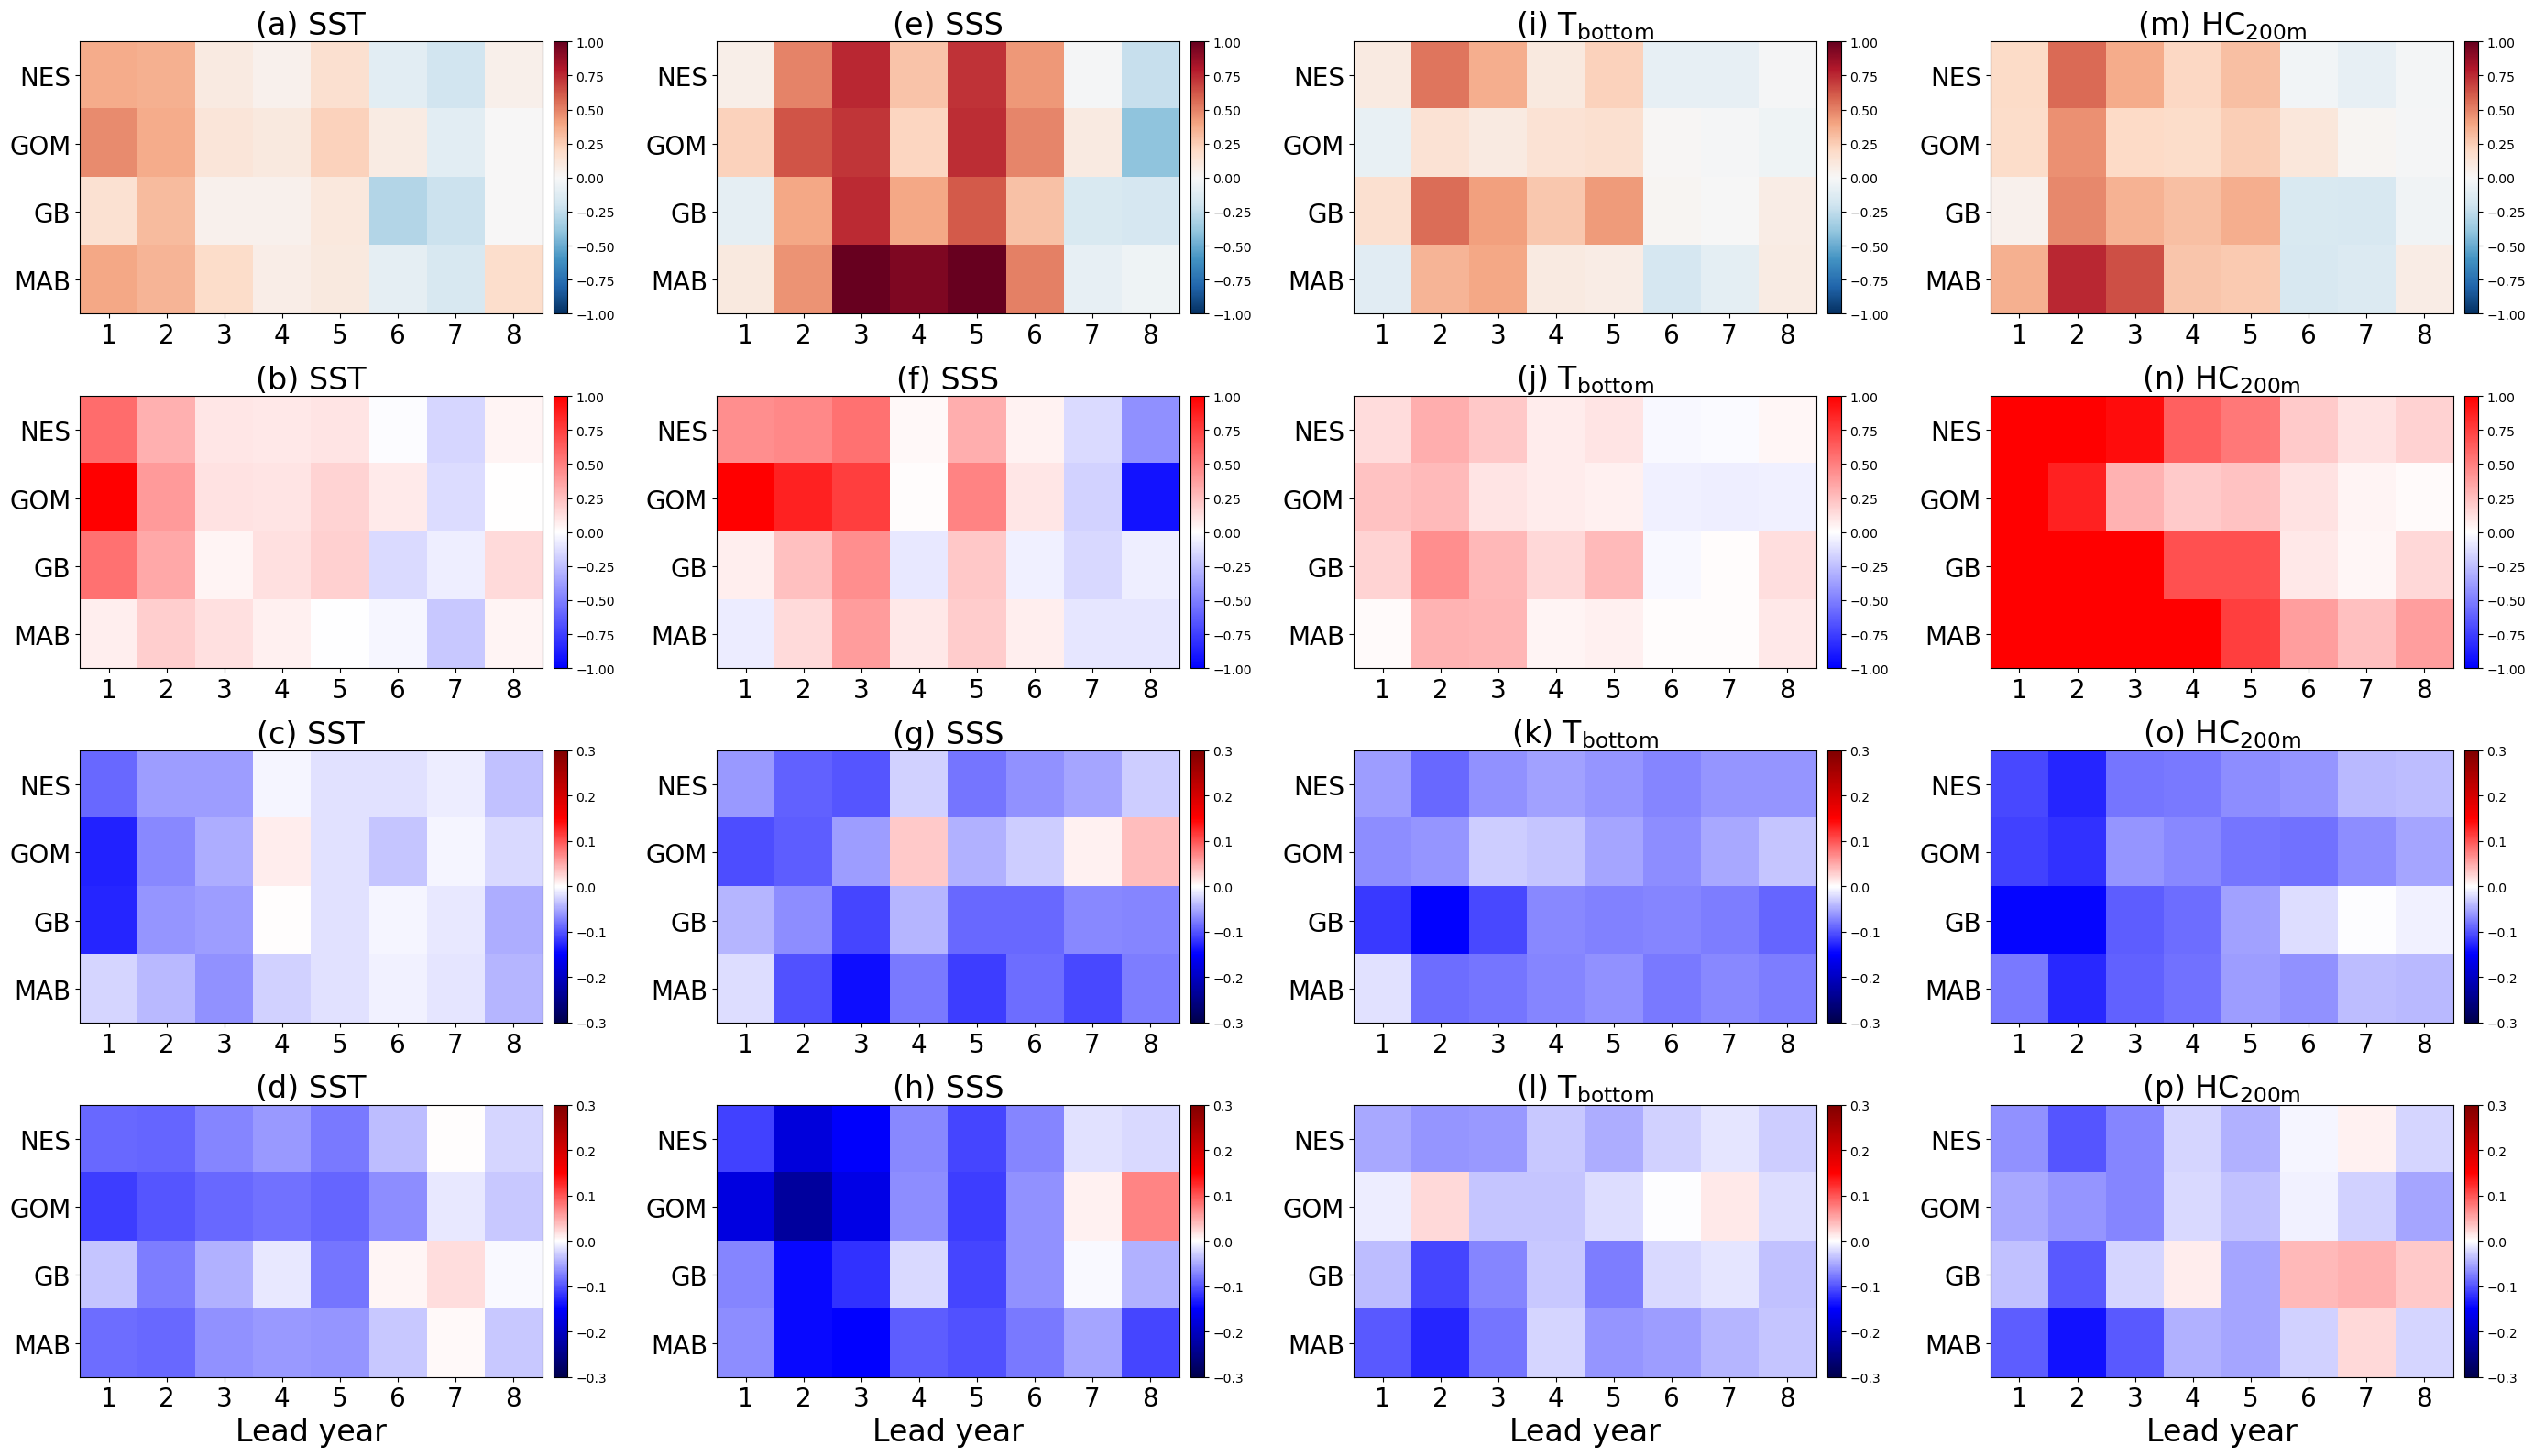

In [46]:
fig, axes = plt.subplots(4, 4, figsize=(28, 16))

variables = ['sst', 'sss', 'bottomT', 'Heat200']
varia_names = ['SST', 'SSS', 'T$_{\\rm{bottom}}$', 'HC$_{\\rm{200m}}$']

regions = ['all', 'GOM', 'GB', 'MAB']
region_names = ['NES', 'GOM', 'GB', 'MAB']
lead_years = np.arange(1, 9)

fs = 24
jroms1 = 70; jroms2 = 370
iroms1 = 50; iroms2 = 600

panel = 0  # for (a)-(p)

for v, varia in enumerate(variables):

    # ===================== ROW 0: ACC =====================
    acc_diff = np.zeros((len(regions), len(lead_years)))
    for i, region in enumerate(regions):
        acc_roms = vars()[f'mean_acc_{varia}_roms_{region}']
        acc_dple = vars()[f'mean_acc_{varia}_dple40_{region}']
        acc_diff[i, :] = acc_roms - acc_dple

    ax = axes[0, v]
    im = ax.imshow(acc_diff, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_title(f'({chr(97+panel)}) {varia_names[v]}', fontsize=fs)
    panel += 1
    fig.colorbar(im, ax=ax, pad=0.02)

    # ===================== ROW 1: MSSS =====================
    msss_diff = np.zeros((len(regions), len(lead_years)))
    with nc.Dataset(msss_file, 'r') as dataset:
        for i, region in enumerate(regions):
            msss_roms = np.nanmean(
                dataset.variables[f'msss_{varia}_roms'][:, jroms1:jroms2, iroms1:iroms2]
                * vars()[f'{region}_mask'],
                axis=(1, 2)
            )
            msss_dple = np.nanmean(
                dataset.variables[f'msss_{varia}_dple40'][:, jroms1:jroms2, iroms1:iroms2]
                * vars()[f'{region}_mask'],
                axis=(1, 2)
            )
            msss_diff[i, :] = msss_roms - msss_dple

    ax = axes[1, v]
    im = ax.imshow(msss_diff, vmin=-1, vmax=1, cmap='bwr', aspect='auto')
    ax.set_title(f'({chr(97+panel)}) {varia_names[v]}', fontsize=fs)
    panel += 1
    fig.colorbar(im, ax=ax, pad=0.02)

    # ===================== ROW 2: BrS Upper =====================
    brs_diff = np.zeros((len(regions), len(lead_years)))
    for i, region in enumerate(regions):
        brs_roms = np.mean(vars()[f'{varia}_upper_brier_score_{region}_roms'], axis=0)
        brs_dple = np.mean(vars()[f'{varia}_upper_brier_score_{region}_dple'], axis=0)
        brs_diff[i, :] = brs_roms - brs_dple

    ax = axes[2, v]
    im = ax.imshow(brs_diff, vmin=-0.3, vmax=0.3, cmap='seismic', aspect='auto')
    ax.set_title(f'({chr(97+panel)}) {varia_names[v]}', fontsize=fs)
    panel += 1
    fig.colorbar(im, ax=ax, pad=0.02)

    # ===================== ROW 3: BrS Lower =====================
    brs_diff = np.zeros((len(regions), len(lead_years)))
    for i, region in enumerate(regions):
        brs_roms = np.mean(vars()[f'{varia}_lower_brier_score_{region}_roms'], axis=0)
        brs_dple = np.mean(vars()[f'{varia}_lower_brier_score_{region}_dple'], axis=0)
        brs_diff[i, :] = brs_roms - brs_dple

    ax = axes[3, v]
    im = ax.imshow(brs_diff, vmin=-0.3, vmax=0.3, cmap='seismic', aspect='auto')
    ax.set_title(f'({chr(97+panel)}) {varia_names[v]}', fontsize=fs)
    panel += 1
    fig.colorbar(im, ax=ax, pad=0.02)


for r in range(4):
    for c in range(4):
        ax = axes[r, c]
        ax.set_xticks(np.arange(len(lead_years)))
        ax.set_xticklabels(lead_years, fontsize=fs-4)
        ax.set_yticks(np.arange(len(regions)))
        ax.set_yticklabels(region_names, fontsize=fs-4)
        if r == 3:
            ax.set_xlabel('Lead year', fontsize=fs)

plt.tight_layout()


<Font size=5> Figure 9 ACC decomposition of SST

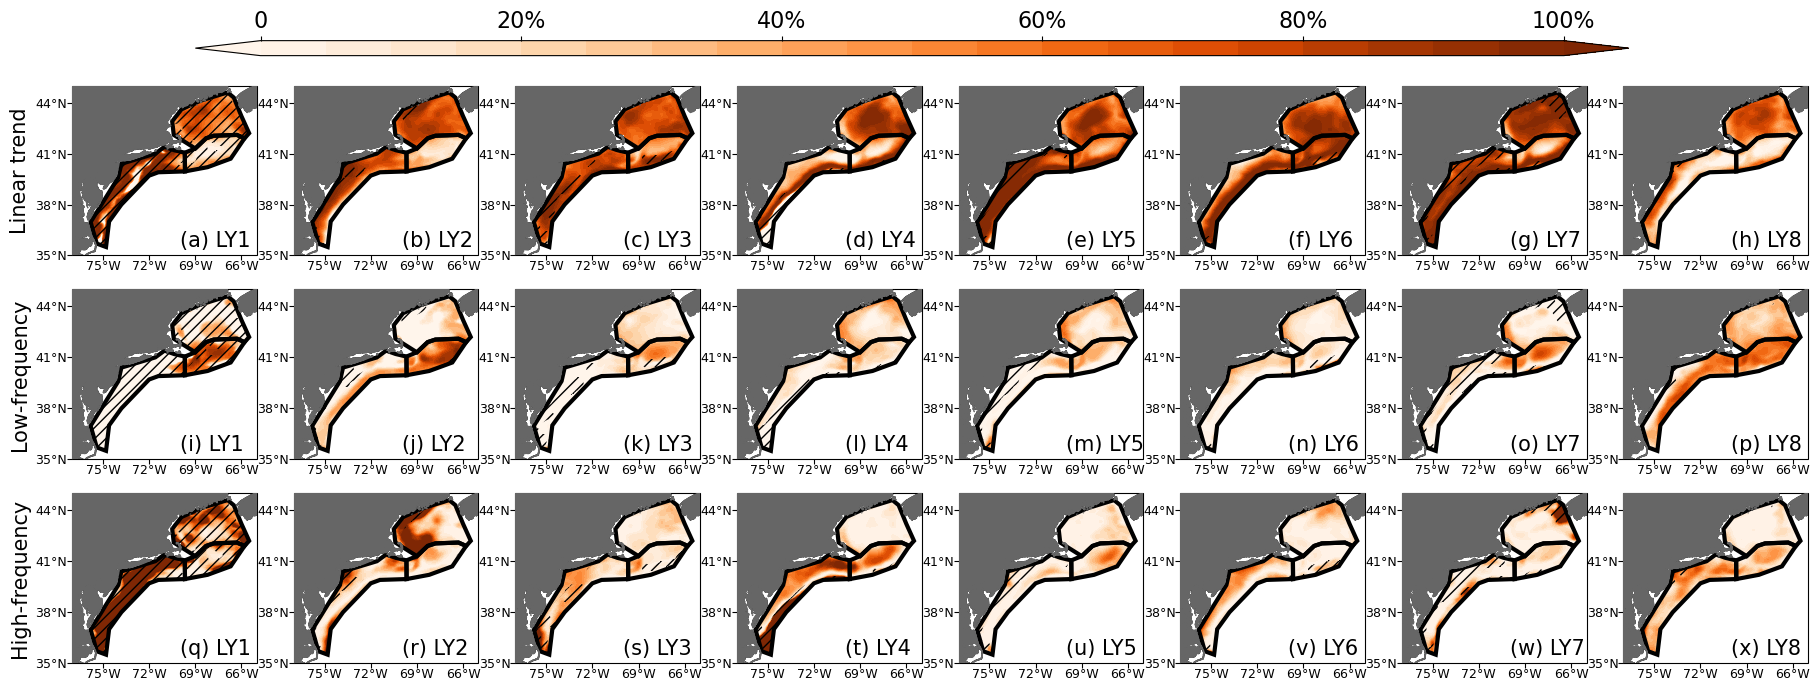

In [48]:
def block_average_2d(arr, block_size=1):
    ny, nx = arr.shape
    by = block_size
    bx = block_size
    # Ensure array is trimmed to be divisible by block size
    trimmed = arr[:ny - ny % by, :nx - nx % bx]
    # Reshape and average
    return trimmed.reshape(ny // by, by, nx // bx, bx).mean(axis=(1, 3))

outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'
jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;

sources = ['roms']#,'dple40','lens'];
sour_names = ['ROMS-DOWN','CESM-DPLE','CESM-LE']
variables = ['sst']#,'ssh','sss','bottomT','Heat200'];
varia_names = ['SST','SSH','SSS','T$_{\\rm{bottom}}$','HC$_{\\rm{200m}}$']
types = ['']#,'_detrended','_highpassed']#,'_nolens40'];
contributions = ['trend','decadal','high']
contribution_names = ['Linear trend', 'Low-frequency', 'High-frequency']
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)','(w)','(x)','(y)','(z)']

colormaps = ['Oranges','Purples','Blues']
colormaps = ['Oranges','Purples','Blues','Oranges','Purples']

nrows = len(contributions); ncols = len(FY);
subplot_width = 2.8; subplot_height = 2.5;
figsize = (ncols * subplot_width, nrows * subplot_height)

for v,varia in enumerate(variables):
    for i, sour in enumerate(sources):
        fig = plt.figure(figsize=figsize); fs=11; leap = 20; lw=1;
        for j,tau in enumerate(FY):
            dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_ACC_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
            acc_full = dataset.variables['acc_'+varia+'_'+sour][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            pacc_full = dataset.variables['pacc_'+varia+'_'+sour][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            acc_detrend = dataset.variables['acc_'+varia+'_'+sour+'_detrended'][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            acc_high = dataset.variables['acc_'+varia+'_'+sour+'_highpassed'][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            lon_roms = dataset.variables['lon_roms'][jroms1:jroms2,iroms1:iroms2]
            lat_roms = dataset.variables['lat_roms'][jroms1:jroms2,iroms1:iroms2]
            dataset.close();
            contri_trend = (acc_full**2-acc_detrend**2)/acc_full**2
            contri_decadal = (acc_detrend**2-acc_high**2)/acc_full**2
            contri_high = (acc_high**2)/acc_full**2;
            for c,contri in enumerate(contributions):
                k = c*ncols+j;
                m=fig.add_subplot(nrows,ncols,k+1,projection=ccrs.PlateCarree(central_longitude=-180))
                cont = m.contourf(block_average_2d(lon_roms),block_average_2d(lat_roms),100*block_average_2d(vars()['contri_'+contri]),np.linspace(0,100,21),extend='both',cmap=colormaps[v],transform = ccrs.PlateCarree());

                condition = (pacc_full >= 0.05) & (~np.isnan(all_mask))  # p < 0.05
                hatch_contour = m.contourf(lon_roms,lat_roms, condition, colors='none', levels=[0.5,1.5],hatches=['///'], transform=ccrs.PlateCarree())
                
                m.coastlines();m.set_aspect('auto', adjustable=None)
                m.add_feature(cartopy.feature.LAND,zorder=100,color=[0.4,0.4,0.4])
                m.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
                m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-2,pad=0);
                m.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
                m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-2,pad=0);
                m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
                #plt.title(labels[c*len(FY)+j]+' Lead year '+str(tau), fontsize=fs, pad=0)
                m.text(-70,35.5,labels[c*len(FY)+j]+' LY'+str(tau),fontsize=fs+4,color='k',zorder=200, transform=ccrs.PlateCarree())
                if c*len(FY)+j in [0,8,16]:
                    m.set_ylabel(contribution_names[c],fontsize=fs+4)
                        
                for r in ['GOM','MAB','GB']:#['all','SMAB','NMAB','WGOM','EGOM','GB']:
                    polygon_outline = patches.Polygon(vars()[r+'_coords'],closed=True, edgecolor='k', linewidth=3, facecolor='none',transform = ccrs.PlateCarree())
                    m.add_patch(polygon_outline);
        cbar_ax = fig.add_axes([0.18, 0.92, 0.64, 0.02])  # [left, bottom, width, height]
        cbar = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        cbar.ax.xaxis.set_ticks_position('top'); cbar.ax.xaxis.set_label_position('top');
        cbar.ax.tick_params(labelsize=fs + 5, pad=2); 
        cbar.set_ticks([0,20,40,60,80,100]); cbar.set_ticklabels(['0','20%','40%','60%','80%','100%'])


<font size=5> Figure 10 Time Series of SSS

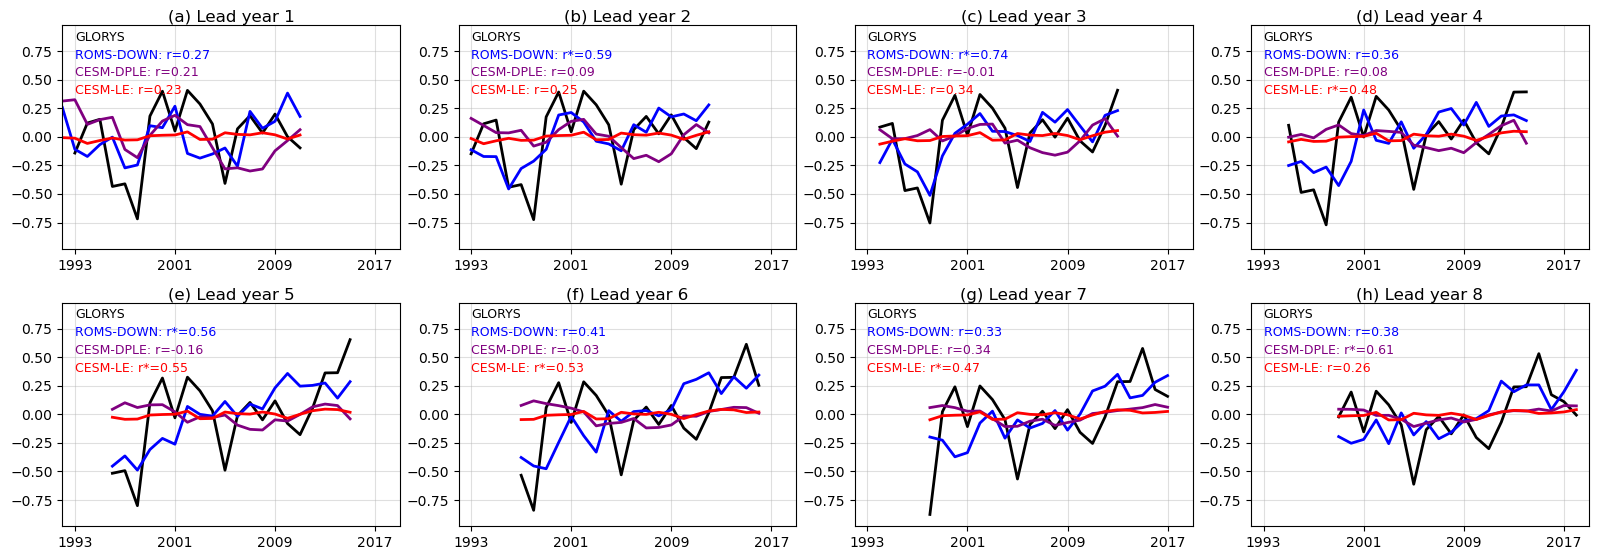

In [3]:
#regional mean time series and decomposition
outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'

jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;
i1_north = 750; i2_north = 1050; j1_north = 380; j2_north = 466;
i1_south = 350; i2_south = 650; j1_south = 0; j2_south = 90;

sources = ['glorys','roms','dple40','lens'];
variables = ['sss'];
varia_names = ['SSS']
types = [''] #,'_detrended','_highpassed']#,'_nolens40'];
regions = ['all']

for v,varia in enumerate(variables):
    for j, sour in enumerate(sources):
        for i, region in enumerate(regions):
            for t, ty in enumerate(types):
                vars()[varia+'_anomaly_'+sour+'_'+region+ty] = np.zeros((len(Start_years),len(FY)));
            for fy in FY:
                dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc');
                if region in ['north','south']:
                    j1=vars()['j1_'+region]; j2 = vars()['j2_'+region];
                    i1=vars()['i1_'+region]; i2 = vars()['i2_'+region];
                    data0 = np.nanmean(dataset.variables[varia+'_'+sour+'_anomaly'][:,fy-1,j1:j2,i1:i2],axis=(1,2))
                else:
                    data0 = np.nanmean(dataset.variables[varia+'_'+sour+'_anomaly'][:,fy-1,jroms1:jroms2,iroms1:iroms2]*vars()[region + '_mask'][None,:,:],axis=(1,2))
                dataset.close();
                ####raw series
                vars()[varia+'_anomaly_'+sour+'_'+region][:,fy-1] = data0
#                 ####detrended series
#                 vars()[varia+'_anomaly_'+sour+'_'+region+'_detrended'][:,fy-1] = detrend_series(data0);
#                 ####high-passed series
#                 vars()[varia+'_anomaly_'+sour+'_'+region+'_highpassed'][:,fy-1] = data0-lowpass_filter_1d(data0, cutoff_years=10, fs=1.0)

sources = ['glorys','roms','dple40','lens'];
variables = ['sss'];
varia_names = ['SSS']
units = ['']
types = ['']#,'_detrended','_highpassed']#,'_nolens40'];
type_names = ['']#,'w/o trend','w/o low-freq']
regions = ['all']#, 'GOM', 'GB','MAB']
region_names = ['NES']#, 'GOM', 'GB','MAB']
colors = ['black','blue','purple','red']
line_labels = ['GLORYS','ROMS-DOWN','CESM-DPLE','CESM-LE']
fs = 12; lw = 2;
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)','(w)','(x)','(y)','(z)']

text_x = 1993  # year (x-axis) where the text will be placed
ylim1 = [-0.98];
ylim2 = [0.98];
for v, varia in enumerate(variables):
    y_min = ylim1[v]; y_max = ylim2[v]; y_range = y_max - y_min;
    text_y_start = y_max - 0.07 * y_range   # 5% below the top
    text_y_gap = 0.08 * y_range             # 8% vertical gap
    for i, region in enumerate(regions):
        for t, ty in enumerate(types):
            fig, axs = plt.subplots(2, 4, figsize=(16, 6))
            axs = axs.flatten()
            for fy in FY:
                ax = axs[fy - 1]
                xyear = Start_years + fy - 1
                y_text = text_y_start
                for j, sour in enumerate(sources):
                    data = vars()[varia + '_anomaly_' + sour + '_' + region + ty][:, fy - 1]
                    ax.plot(xyear, data, color=colors[j], linewidth=lw)
                    if sour in ['roms', 'dple40', 'lens']:
                        data0 = vars()[varia + '_anomaly_glorys_' + region + ty][:, fy - 1]
                        mask = ~np.isnan(data) & ~np.isnan(data0)
                        r_val, p_val = pearsonr(data[mask], data0[mask])
#                         p_str = "p<0.05" if p_val < 0.05 else "p>0.05"
#                         label_str = f"{line_labels[j]}: r={r_val:.2f}, {p_str}"
                        r_label = f"r*={r_val:.2f}" if p_val < 0.05 else f"r={r_val:.2f}"
                        p_str = "p<0.05" if p_val < 0.05 else "p>0.05"
                        label_str = f"{line_labels[j]}: {r_label}" #, {p_str}"

                        ax.text(text_x, y_text, label_str,color=colors[j], fontsize=fs-3, transform=ax.transData)
                        y_text -= text_y_gap
                    elif sour == 'glorys':
                        label_str = f"{line_labels[j]}"
                        ax.text(text_x, y_text, label_str,color=colors[j], fontsize=fs-3, transform=ax.transData)
                        y_text -= text_y_gap

                ax.set_xticks(np.arange(1993, 2020, 8))
                ax.set_xlim(1992, 2019)
                ax.set_ylim(ylim1[v],ylim2[v])  # adjust if needed
                ax.grid(True, alpha=0.4)
                ax.set_title(labels[fy-1]+' Lead year '+str(fy), pad=1, fontsize=fs)
                if fy in [1,5]:
                    ax.set_ylabel(units[v],fontsize=fs)
            title = f"{varia_names[v]} {type_names[t]} [{region_names[i]}]" if t > 0 else f"{varia_names[v]} [{region_names[i]}]"
            #fig.suptitle(title,y=0.92, fontsize=fs+2)
            fig.tight_layout(rect=[0, 0, 1, 0.95])            


<font size=5> Figure 11 ACC decomposition of SSS

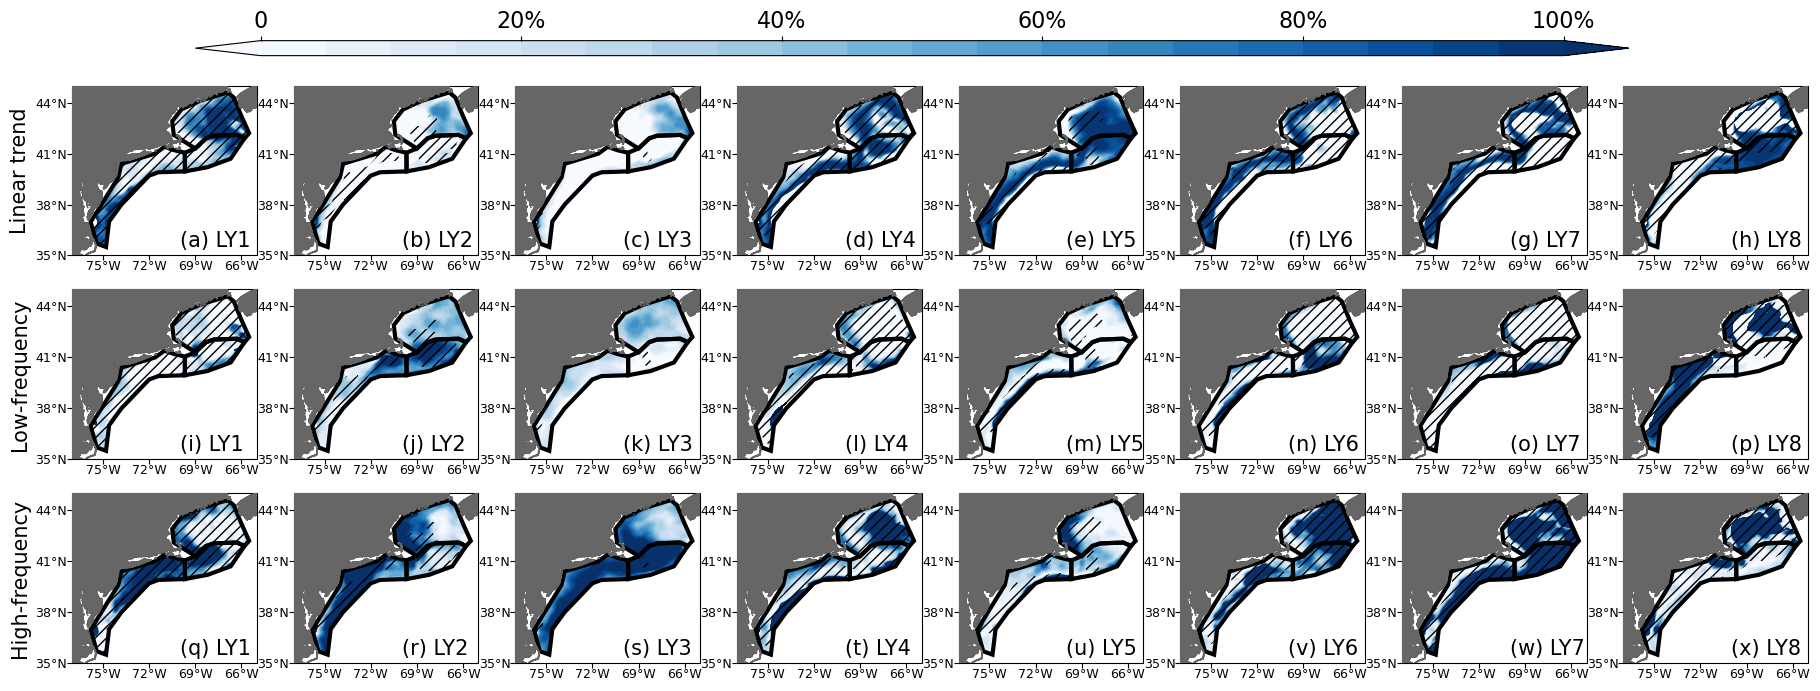

In [3]:
def block_average_2d(arr, block_size=1):
    ny, nx = arr.shape
    by = block_size
    bx = block_size
    # Ensure array is trimmed to be divisible by block size
    trimmed = arr[:ny - ny % by, :nx - nx % bx]
    # Reshape and average
    return trimmed.reshape(ny // by, by, nx // bx, bx).mean(axis=(1, 3))

outpath = '/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis_2/'
jroms1 = 70; jroms2 = 370; iroms1 = 50; iroms2 = 600;

sources = ['roms']#,'dple40','lens'];
sour_names = ['ROMS-DOWN','CESM-DPLE','CESM-LE']
variables = ['sss'];
varia_names = ['SSS']
types = ['']#,'_detrended','_highpassed']#,'_nolens40'];
contributions = ['trend','decadal','high']
contribution_names = ['Linear trend', 'Low-frequency', 'High-frequency']
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)','(w)','(x)','(y)','(z)']

colormaps = ['Blues']

nrows = len(contributions); ncols = len(FY);
subplot_width = 2.8; subplot_height = 2.5;
figsize = (ncols * subplot_width, nrows * subplot_height)

for v,varia in enumerate(variables):
    for i, sour in enumerate(sources):
        fig = plt.figure(figsize=figsize); fs=11; leap = 20; lw=1;
        for j,tau in enumerate(FY):
            dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_ACC_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
            acc_full = dataset.variables['acc_'+varia+'_'+sour][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            pacc_full = dataset.variables['pacc_'+varia+'_'+sour][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            acc_detrend = dataset.variables['acc_'+varia+'_'+sour+'_detrended'][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            acc_high = dataset.variables['acc_'+varia+'_'+sour+'_highpassed'][tau-1,jroms1:jroms2,iroms1:iroms2]*all_mask
            lon_roms = dataset.variables['lon_roms'][jroms1:jroms2,iroms1:iroms2]
            lat_roms = dataset.variables['lat_roms'][jroms1:jroms2,iroms1:iroms2]
            dataset.close();
            contri_trend = (acc_full**2-acc_detrend**2)/acc_full**2
            contri_decadal = (acc_detrend**2-acc_high**2)/acc_full**2
            contri_high = (acc_high**2)/acc_full**2;
            for c,contri in enumerate(contributions):
                k = c*ncols+j;
                m=fig.add_subplot(nrows,ncols,k+1,projection=ccrs.PlateCarree(central_longitude=-180))
                cont = m.contourf(block_average_2d(lon_roms),block_average_2d(lat_roms),100*block_average_2d(vars()['contri_'+contri]),np.linspace(0,100,21),extend='both',cmap=colormaps[v],transform = ccrs.PlateCarree());

                condition = (pacc_full >= 0.05) & (~np.isnan(all_mask))  # p < 0.05
                hatch_contour = m.contourf(lon_roms,lat_roms, condition, colors='none', levels=[0.5,1.5],hatches=['///'], transform=ccrs.PlateCarree())
                
                m.coastlines();m.set_aspect('auto', adjustable=None)
                m.add_feature(cartopy.feature.LAND,zorder=100,color=[0.4,0.4,0.4])
                m.set_xticks(np.arange(285,315,3),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
                m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-2,pad=0);
                m.set_yticks(np.arange(32,52,3),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
                m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-2,pad=0);
                m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
                #plt.title(labels[c*len(FY)+j]+' Lead year '+str(tau), fontsize=fs, pad=0)
                m.text(-70,35.5,labels[c*len(FY)+j]+' LY'+str(tau),fontsize=fs+4,color='k',zorder=200, transform=ccrs.PlateCarree())
                if c*len(FY)+j in [0,8,16]:
                    m.set_ylabel(contribution_names[c],fontsize=fs+4)
                        
                for r in ['GOM','MAB','GB']:#['all','SMAB','NMAB','WGOM','EGOM','GB']:
                    polygon_outline = patches.Polygon(vars()[r+'_coords'],closed=True, edgecolor='k', linewidth=3, facecolor='none',transform = ccrs.PlateCarree())
                    m.add_patch(polygon_outline);
        cbar_ax = fig.add_axes([0.18, 0.92, 0.64, 0.02])  # [left, bottom, width, height]
        cbar = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        cbar.ax.xaxis.set_ticks_position('top'); cbar.ax.xaxis.set_label_position('top');
        cbar.ax.tick_params(labelsize=fs + 5, pad=2); 
        cbar.set_ticks([0,20,40,60,80,100]); cbar.set_ticklabels(['0','20%','40%','60%','80%','100%'])


<font size=5> Figure 12 MAB Cold Pool Maps

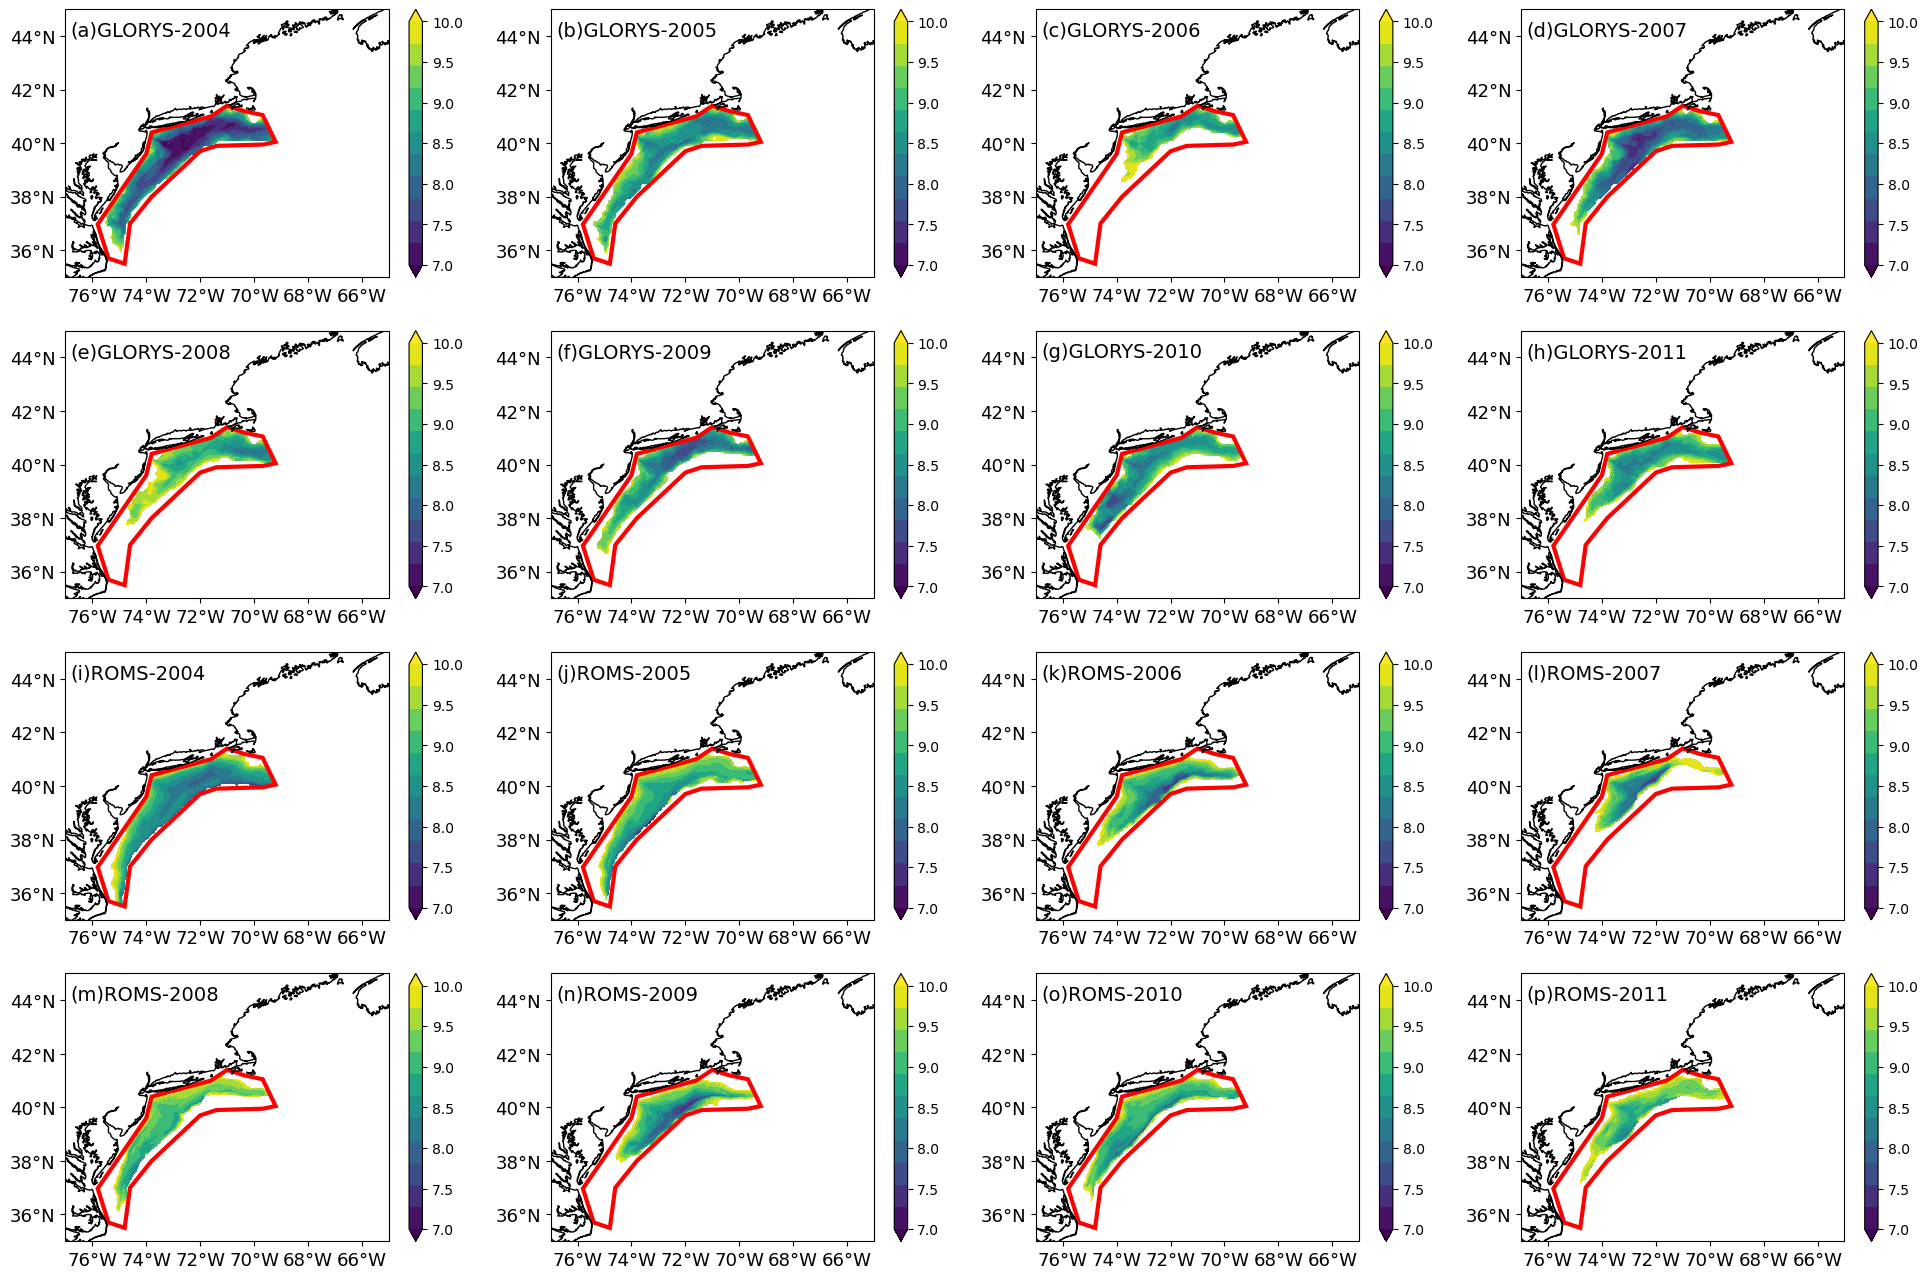

In [23]:
###mon: 0:June; 1:July; 2:August; 3:September
ColdPool_coords = [(-74.8,35.5),(-75.4,35.7),(-75.8,36.97),(-74,39.6),(-73.8,40.4)
                   ,(-71.6,41.0),(-71.0,41.4),(-70.38,41.2),(-69.68,41.05)
                   ,(-69.2,40.05),(-69.67,39.95),(-71.4,39.9),(-72,39.7),(-73.8,38.0),(-74.6,37)]
ColdPool_polygon = Polygon(ColdPool_coords)

year1 = 2004; year2 = 2012; nyears = year2-year1;
glorys_dataset = nc.Dataset('/proj/nes/post_processed/GLORYS_temp_cold_pool_1993_2019.nc','r')
coldpool_glorys = glorys_dataset.variables['temp_cold_pool'][year1-1993:year2-1993,:,:,:]
lat_glorys = glorys_dataset.variables['lat'][:]
lon_glorys = glorys_dataset.variables['lon'][:]
glorys_dataset.close();
roms_dataset = nc.Dataset('/proj/nes/post_processed/ROMS_Downscaling_temp_cold_pool_SY1992_SY2011_LY1_8.nc','r')
coldpool_roms = np.nanmean(roms_dataset.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:],axis=0)
lat_roms = roms_dataset.variables['lat_roms'][:]
lon_roms = roms_dataset.variables['lon_roms'][:]
roms_dataset.close();

sources = ['glorys','roms']
source_names = ['GLORYS','ROMS']
labels = ['(a)','(b)','(c)', '(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)','(u)','(v)','(w)','(x)','(y)','(z)']

clev = np.linspace(7,10,12)
fig = plt.figure(figsize=(24,16)); fs=15; kk = 0;
for s,sour in enumerate(sources):
    for yr in range(nyears):
        m=fig.add_subplot(4,4,kk+1,projection=ccrs.PlateCarree(central_longitude=-180))
        cont = m.contourf(vars()['lon_'+sour],vars()['lat_'+sour],np.nanmean(vars()['coldpool_'+sour][yr,:,:,:],axis=0),levels=clev,extend='both',transform = ccrs.PlateCarree());
        cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
        m.coastlines();m.set_aspect('auto', adjustable=None)
        m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
        m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-2);
        m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
        m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-2);
        m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());                        
        polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3, facecolor='none',transform = ccrs.PlateCarree())
        m.add_patch(polygon_outline);
        m.text(-76.8,44,labels[kk]+source_names[s]+'-'+str(yr+year1),fontsize=fs-1,color='k',zorder=200, transform=ccrs.PlateCarree())

        kk+=1;


<font size=5> Figure 13 Time Series and ACC of Cold Pool

In [3]:
###Cold Pool Index: mean temperature and volume
year1 = 2004; year2 = 2009; nyears = year2-year1;
glorys_dataset = nc.Dataset('/proj/nes/post_processed/GLORYS_temp_cold_pool_Jun_Sep_1993_2019.nc','r')
coldpool_glorys = np.nanmean(glorys_dataset.variables['temp_cold_pool'][year1-1993:year2-1993,:,:,:,:],axis=(1,2,3,4))#year,month(4),depth,lat,lon
lat_glorys = glorys_dataset.variables['lat'][:]
lon_glorys = glorys_dataset.variables['lon'][:]
glorys_z = glorys_dataset.variables['depth'][:]
R = 6371000  # Earth radius in meters
lat_rad = np.radians(lat_glorys)
lon_rad = np.radians(lon_glorys)
dlat = np.diff(lat_rad)
dy = R * dlat
dy_full = np.append(dy, dy[-1])  # extend to match grid size
dx = np.zeros((len(lat_glorys), len(lon_glorys)-1))
for j, lat in enumerate(lat_rad):
    dlon = np.diff(lon_rad)
    dx[j, :] = R * np.cos(lat) * dlon
dx_full = np.pad(dx, ((0,0), (0,1)), mode='edge')  # pad to match grid size
z = glorys_z
dz = np.diff(z)
dz = np.append(dz, dz[-1])  # shape: (depth,)
dx_2d, dy_2d = np.meshgrid(dx_full[0], dy_full)
area = dx_2d * dy_2d  # shape: [lat, lon]
volume_glorys = dz[:, np.newaxis, np.newaxis] * area[np.newaxis, :, :]/1e9
coldpool = np.nanmean(glorys_dataset.variables['temp_cold_pool'][year1-1993:year2-1993,:,:,:,:],axis=(1))#year,month(4),depth,lat,lon
extent_glorys = np.zeros((coldpool.shape[0]))
for yr in range(coldpool.shape[0]):
    temp = coldpool[yr,:,:,:]
    temp[np.where(np.isnan(temp)==0)] = 1;
    extent_glorys[yr] = np.nansum(temp*volume_glorys)
glorys_dataset.close();

hind_dataset = nc.Dataset('/proj/nes/post_processed/ROMS_Hindcast_temp_cold_pool_Jun_Sep_2004_2009.nc','r')
coldpool_hind = np.nanmean(hind_dataset.variables['temp_cold_pool'][year1-2004:year2-2004,:,:,:,:],axis=(1,2,3,4))#year,month(4),depth,lat,lon
lat_hind = hind_dataset.variables['lat_roms'][:]
lon_hind = hind_dataset.variables['lon_roms'][:]
depth_hind = hind_dataset.variables['roms_depth'][:]
nz, ny, nx = depth_hind.shape
lat_rad = np.radians(lat_hind)
lon_rad = np.radians(lon_hind)
dy = np.zeros((ny, nx))
dx = np.zeros((ny, nx))
for j in range(1, ny):
    dy[j, :] = R * (lat_rad[j, :] - lat_rad[j - 1, :])
dy[0, :] = dy[1, :]  # replicate first row
for i in range(1, nx):
    dx[:, i] = R * np.cos(lat_rad[:, i]) * (lon_rad[:, i] - lon_rad[:, i - 1])
dx[:, 0] = dx[:, 1]  # replicate first column
dx = np.abs(dx)
dy = np.abs(dy)
area = dx * dy  # shape: (lat, lon)
dz = np.diff(depth_hind, axis=0)  # shape: (z-1, lat, lon)
dz_last = dz[-1, :, :][np.newaxis, :, :]
dz = np.concatenate((dz, dz_last), axis=0)  # shape: (z, lat, lon)
volume_roms = abs(dz) * area[np.newaxis, :, :]/1e9  # shape: (z, lat, lon)
coldpool = np.nanmean(hind_dataset.variables['temp_cold_pool'][year1-2004:year2-2004,:,:,:,:],axis=(1))#year,month(4),depth,lat,lon
extent_hind = np.zeros((coldpool.shape[0]))
for yr in range(coldpool.shape[0]):
    temp = coldpool[yr,:,:,:]
    temp[np.where(np.isnan(temp)==0)] = 1;
    extent_hind[yr] = np.nansum(temp*volume_roms)
hind_dataset.close();

roms_dataset = nc.Dataset('/proj/nes/post_processed/ROMS_Downscaling_temp_cold_pool_Jun_Sep_SY1992_SY2011_LY1_8.nc','r')
coldpool_roms = np.nanmean(roms_dataset.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:,:],axis=(0,2,3,4,5))#Start year,ens,FY,month(4),depth,lat,lon
lat_roms = roms_dataset.variables['lat_roms'][:]
lon_roms = roms_dataset.variables['lon_roms'][:]
coldpool = np.nanmean(roms_dataset.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:,:],axis=(0,2))#Start year,ens,FY,month(4),depth,lat,lon
extent_roms = np.zeros((coldpool.shape[0]))
for yr in range(coldpool.shape[0]):
    temp = coldpool[yr,:,:,:]
    temp[np.where(np.isnan(temp)==0)] = 1;
    extent_roms[yr] = np.nansum(temp*volume_roms)
roms_dataset.close();


In [7]:
###Cold Pool Index: mean temperature and volume
glorys_dataset = nc.Dataset('/proj/nes/post_processed/GLORYS_temp_cold_pool_Jun_Sep_1993_2019.nc','r')
lat_glorys = glorys_dataset.variables['lat'][:]
lon_glorys = glorys_dataset.variables['lon'][:]
glorys_z = glorys_dataset.variables['depth'][:]
R = 6371000  # Earth radius in meters
lat_rad = np.radians(lat_glorys); lon_rad = np.radians(lon_glorys);
dlat = np.diff(lat_rad);
dy = R * dlat; dy_full = np.append(dy, dy[-1])  # extend to match grid size
dx = np.zeros((len(lat_glorys), len(lon_glorys)-1))
for j, lat in enumerate(lat_rad):
    dlon = np.diff(lon_rad)
    dx[j, :] = R * np.cos(lat) * dlon
dx_full = np.pad(dx, ((0,0), (0,1)), mode='edge')  # pad to match grid size
z = glorys_z; dz = np.diff(z); dz = np.append(dz, dz[-1])  # shape: (depth,)
dx_2d, dy_2d = np.meshgrid(dx_full[0], dy_full)
area = dx_2d * dy_2d  # shape: [lat, lon]
volume_glorys = dz[:, np.newaxis, np.newaxis] * area[np.newaxis, :, :]/1e9
glorys_dataset.close();
glorys_dataset = nc.Dataset('/proj/nes/post_processed/GLORYS_temp_cold_pool_Jun_Sep_1993_2019.nc','r')
cp_temp_glorys = np.nanmean(glorys_dataset.variables['temp_cold_pool'][:,:,:,:,:],axis=(1,2,3,4))#year,month(4),depth,lat,lon
coldpool = np.nanmean(glorys_dataset.variables['temp_cold_pool'][:,:,:,:,:],axis=(1))#year,month(4),depth,lat,lon
cp_volume_glorys = np.zeros((coldpool.shape[0]))
for yr in range(coldpool.shape[0]):
    temp = coldpool[yr,:,:,:]
    temp[np.where(np.isnan(temp)==0)] = 1;
    cp_volume_glorys[yr] = np.nansum(temp*volume_glorys)
glorys_dataset.close();

hind_dataset = nc.Dataset('/proj/nes/post_processed/ROMS_Hindcast_temp_cold_pool_Jun_Sep_2004_2009.nc','r')
lat_hind = hind_dataset.variables['lat_roms'][:]
lon_hind = hind_dataset.variables['lon_roms'][:]
depth_hind = hind_dataset.variables['roms_depth'][:]
nz, ny, nx = depth_hind.shape
lat_rad = np.radians(lat_hind); lon_rad = np.radians(lon_hind);
dy = np.zeros((ny, nx)); dx = np.zeros((ny, nx));
for j in range(1, ny):
    dy[j, :] = R * (lat_rad[j, :] - lat_rad[j - 1, :])
dy[0, :] = dy[1, :]  # replicate first row
for i in range(1, nx):
    dx[:, i] = R * np.cos(lat_rad[:, i]) * (lon_rad[:, i] - lon_rad[:, i - 1])
dx[:, 0] = dx[:, 1]  # replicate first column
dx = np.abs(dx); dy = np.abs(dy);
area = dx * dy  # shape: (lat, lon)
dz = np.diff(depth_hind, axis=0)  # shape: (z-1, lat, lon)
dz_last = dz[-1, :, :][np.newaxis, :, :]
dz = np.concatenate((dz, dz_last), axis=0)  # shape: (z, lat, lon)
volume_roms = abs(dz) * area[np.newaxis, :, :]/1e9  # shape: (z, lat, lon)
hind_dataset.close();

roms_dataset = nc.Dataset('/proj/nes/post_processed/ROMS_Downscaling_temp_cold_pool_Jun_Sep_SY1992_SY2011_LY1_8.nc','r')
cp_temp_roms = np.zeros((len(Start_years),len(FY)))
for sy in range(len(Start_years)):
    for fy in range(len(FY)):
        data = roms_dataset.variables['temp_cold_pool'][sy,:,fy,:,:,:,:]
        data[data.mask] = np.nan
        cp_temp_roms[sy,fy] = np.nanmean(data)#Start year,ens,FY,month(4),depth,lat,lon
lat_roms = roms_dataset.variables['lat_roms'][:]
lon_roms = roms_dataset.variables['lon_roms'][:]
cp_volume_roms = np.zeros((len(Start_years),len(FY)))
for sy in range(len(Start_years)):
    for fy in range(len(FY)):
        temp = np.nanmean(roms_dataset.variables['temp_cold_pool'][sy,:,fy,:,:,:,:],axis=(0,1))#Start year,ens,FY,month(4),depth,lat,lon
        temp[np.where(np.isnan(temp)==0)] = 1;
        cp_volume_roms[sy,fy] = np.nansum(temp*volume_roms)
roms_dataset.close();

def calculate_acc(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]
    n = len(x)
    x_anom = x - np.mean(x)
    y_anom = y - np.mean(y)
    numerator = np.sum(x_anom * y_anom)
    denominator = np.sqrt(np.sum(x_anom ** 2) * np.sum(y_anom ** 2))
    acc = numerator / denominator if denominator != 0 else np.nan
    # Calculate t-statistic and p-value
    t_stat = acc * np.sqrt((n - 2) / (1 - acc ** 2))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 2))
    return acc, p_value
def calculate_msss(data1, data2):
    valid_mask = ~np.isnan(data1) & ~np.isnan(data2)
    model = data1[valid_mask]
    obs = data2[valid_mask]
    mse_forecast = np.mean((model - obs) ** 2)
    mse_climatology = np.mean(obs ** 2)
    msss = 1 - (mse_forecast / mse_climatology)
    return msss

glorys_years = np.arange(1993,2020,1);
temp_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
volume_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
for i,start_yr in enumerate(Start_years):
    for j, fy in enumerate(FY):
        real_year = start_yr+fy-1;
        if real_year in glorys_years:
            idx = np.where(glorys_years == real_year)[0][0]
            temp_glorys[i,j] = cp_temp_glorys[idx]
            volume_glorys[i,j] = cp_volume_glorys[idx]
        else:
            volume_glorys[i,j] = np.nan
            temp_glorys[i,j] = np.nan

acc_temp = np.zeros(len(FY)); pacc_temp = np.zeros(len(FY));
acc_volume = np.zeros(len(FY)); pacc_volume = np.zeros(len(FY));
msss_temp = np.zeros(len(FY)); msss_volume = np.zeros(len(FY));
for j, fy in enumerate(FY):
    series2 = temp_glorys[:,j]-np.nanmean(temp_glorys[:,j]); 
    series1 = cp_temp_roms[:,fy-1]-np.nanmean(cp_temp_roms[:,fy-1]);
    acc_temp[fy-1],pacc_temp[fy-1] = calculate_acc(series1,series2);
    msss_temp[fy-1] = calculate_msss(series1,series2);
    series1 = volume_glorys[:,j]-np.nanmean(volume_glorys[:,j]); 
    series2 = cp_volume_roms[:,fy-1]-np.nanmean(cp_volume_roms[:,fy-1]);
    acc_volume[fy-1],pacc_volume[fy-1] = calculate_acc(series1,series2);
    msss_volume[fy-1] = calculate_msss(series1,series2);


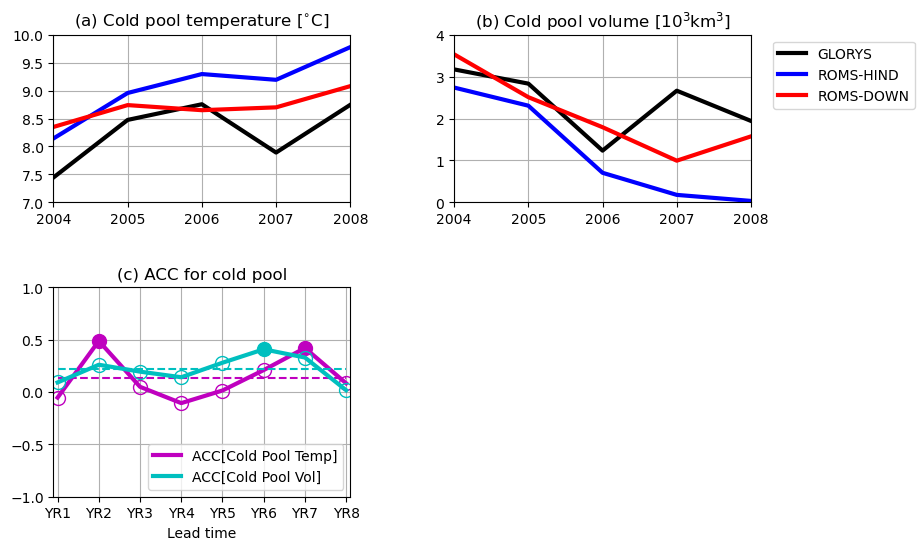

In [10]:
sources = ['glorys', 'hind', 'roms']
source_names = ['GLORYS', 'ROMS-HIND', 'ROMS-DOWN']
colors = ['k', 'b', 'r']
years = np.arange(year1, year2, dtype=int)

lw = 3
ms = 10

fig = plt.figure(figsize=(9, 6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.25], hspace=0.45, wspace=0.35)

# (a)
ax1 = fig.add_subplot(gs[0, 0])
for s, sour in enumerate(sources):
    data = vars()['coldpool_' + sour]
    ax1.plot(years, data, colors[s], linewidth=lw, label=source_names[s])

ax1.set_title('(a) Cold pool temperature [$^{\circ}$C]')
ax1.set_xlim(2004, 2008)
ax1.set_ylim(7, 10)
ax1.set_xticks([2004, 2005, 2006, 2007, 2008])
ax1.grid()

# (b)
ax2 = fig.add_subplot(gs[0, 1])
for s, sour in enumerate(sources):
    data = vars()['extent_' + sour] / 1e3
    ax2.plot(years, data, colors[s], linewidth=lw, label=source_names[s])

ax2.set_title('(b) Cold pool volume [10$^{3}$km$^{3}$]')
ax2.set_xlim(2004, 2008)
ax2.set_ylim(0, 4)
ax2.set_xticks([2004, 2005, 2006, 2007, 2008])
ax2.grid()
ax2.legend(bbox_to_anchor=(1.05, 1.0))

# (c)
ax3 = fig.add_subplot(gs[1, 0])  # instead of gs[1, :]
x = np.arange(acc_temp.size)

ax3.plot(acc_temp, 'm', linewidth=lw, label='ACC[Cold Pool Temp]')
ax3.plot(np.ones(acc_temp.size) * np.mean(acc_temp), '--m')

for xx, y, p in zip(x, acc_temp, pacc_temp):
    mfc = 'm' if p <= 0.2 else 'none'
    ax3.plot(
        xx, y, marker='o', linestyle='none',
        markeredgecolor='m', markerfacecolor=mfc,
        markersize=ms, linewidth=lw
    )

ax3.plot(acc_volume, 'c', linewidth=lw, label='ACC[Cold Pool Vol]')
ax3.plot(np.ones(acc_volume.size) * np.mean(acc_volume), '--c')

for xx, y, p in zip(x, acc_volume, pacc_volume):
    mfc = 'c' if p <= 0.2 else 'none'
    ax3.plot(
        xx, y, marker='o', linestyle='none',
        markeredgecolor='c', markerfacecolor=mfc,
        markersize=ms, linewidth=lw
    )

ax3.set_ylim(-1, 1)
ax3.set_xlim(-0.1, 7.1)
ax3.grid()
ax3.set_xticks(np.arange(0, 8, 1))
ax3.set_xticklabels([f'YR{y+1}' for y in np.arange(8)])
ax3.set_xlabel('Lead time')
ax3.legend(loc='lower right')
ax3.set_title('(c) ACC for cold pool', fontsize=12);


<font size=5> Figure 14 GOM T-S Diagram

In [16]:
# Endmembers in (S, T)
LSW = np.array([34.6,  6.0], dtype=float)
WSW = np.array([35.4, 12.0], dtype=float)
SSW = np.array([32.0,  2.0], dtype=float)

def mixing_ratio(T, S):
    LSW = np.array([34.6, 6.0]); WSW = np.array([35.4, 12.0]); SSW = np.array([32.0, 2.0]);
    A = np.array([S, T])
    # Line from SSW to A: y = m1*x + b1
    m1 = (T - SSW[1]) / (S - SSW[0])
    b1 = SSW[1] - m1 * SSW[0]
    # Line from LSW to WSW: y = m2*x + b2
    m2 = (WSW[1] - LSW[1]) / (WSW[0] - LSW[0])
    b2 = WSW[1] - m2 * WSW[0]
    # Intersection point B: solve m1*x + b1 = m2*x + b2
    xB = (b2 - b1) / (m1 - m2)
    yB = m1 * xB + b1
    B = np.array([xB, yB])
    # Percent slope water (between LSW and WSW)
    dist_LSW_WSW = np.linalg.norm(WSW - LSW)
    dist_LSW_B = np.linalg.norm(B - LSW)
    dist_WSW_B = np.linalg.norm(B - WSW)
    pct_LSW = (dist_WSW_B / dist_LSW_WSW) * 100
    pct_WSW = (dist_LSW_B / dist_LSW_WSW) * 100
    # Percent shelf water (between A and B)
    dist_SSW_B = np.linalg.norm(B - SSW)
    dist_A_B = np.linalg.norm(A - B)
    pct_SSW = (dist_A_B / dist_SSW_B) * 100
    return pct_LSW, pct_WSW, pct_SSW

def calculate_acc(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]
    n = len(x)
    x_anom = x - np.mean(x)
    y_anom = y - np.mean(y)
    numerator = np.sum(x_anom * y_anom)
    denominator = np.sqrt(np.sum(x_anom ** 2) * np.sum(y_anom ** 2))
    acc = numerator / denominator if denominator != 0 else np.nan
    # Calculate t-statistic and p-value
    t_stat = acc * np.sqrt((n - 2) / (1 - acc ** 2))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 2))
    return acc, p_value
def calculate_msss1d(data1, data2):
    valid_mask = ~np.isnan(data1) & ~np.isnan(data2)
    model = data1[valid_mask]
    obs = data2[valid_mask]
    mse_forecast = np.mean((model - obs) ** 2)
    mse_climatology = np.mean(obs ** 2)
    msss = 1 - (mse_forecast / mse_climatology)
    return msss

def calculate_msss(model, obs, block_len=5, n_perm=4000, seed=0):
    rng = np.random.default_rng(seed)

    model = np.asarray(model)
    obs = np.asarray(obs)

    if model.ndim != 1 or obs.ndim != 1:
        raise ValueError(f"Expected 1D arrays. Got model {model.shape}, obs {obs.shape}")
    if model.size != obs.size:
        raise ValueError("model and obs must have the same length")

    nt = model.size
    msss_obs = calculate_msss1d(model, obs)

    # build overlapping blocks of obs
    starts = np.arange(0, nt - block_len + 1)
    blocks = [obs[s:s+block_len] for s in starts]
    n_blocks = int(np.ceil(nt / block_len))

    msss_null = np.empty(n_perm)

    for b in range(n_perm):
        # choose blocks to assemble a permuted obs series
        chosen = rng.integers(0, len(blocks), size=n_blocks)
        obs_perm = np.concatenate([blocks[i] for i in chosen])[:nt]
        msss_null[b] = calculate_msss1d(model, obs_perm)

    # one-sided p-value: P(null >= observed)
    pval = (np.sum(msss_null >= msss_obs) + 1) / (n_perm + 1)

    return msss_obs, pval



dataset = nc.Dataset('/proj/nes/post_processed/GLORYS_slopewater_mixing_ratio_150_200m_1993_2019.nc','r')
temp_slope_glorys0 = np.mean(dataset.variables['temp_slope'][:],axis=1) ###depth mean (two levels in 150-200)
salt_slope_glorys0 = np.mean(dataset.variables['salt_slope'][:],axis=1)
dataset.close();
dataset = nc.Dataset('/proj/nes/post_processed/ROMS_Downscaling_slopewater_mixing_ratio_150_200m_SY'+str(Start_years[0])+'_SY'+str(Start_years[-1])+'_LY1_8.nc','r')
temp_slope_roms = np.mean(dataset.variables['temp_slope'][:],axis=1) #ensemble mean
salt_slope_roms = np.mean(dataset.variables['salt_slope'][:],axis=1)
dataset.close();

dataset = nc.Dataset('/proj/nes/post_processed/DPLE40_slopewater_mixing_ratio_150_200m_SY'+str(Start_years[0])+'_SY'+str(Start_years[-1])+'_LY1_8.nc','r')
temp_slope_dple = np.mean(dataset.variables['temp_slope'][:],axis=1) #ensemble mean
salt_slope_dple = np.mean(dataset.variables['salt_slope'][:],axis=1)
dataset.close();

glorys_years = np.arange(1993,2020,1);
temp_slope_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
salt_slope_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
for i,start_yr in enumerate(Start_years):
    for j, fy in enumerate(FY):
        real_year = start_yr+fy-1;
        if real_year in glorys_years:
            idx = np.where(glorys_years == real_year)[0][0]
            temp_slope_glorys[i,j] = temp_slope_glorys0[idx]
            salt_slope_glorys[i,j] = salt_slope_glorys0[idx]            
    
percent_LSW_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
percent_WSW_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
percent_SSW_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
percent_LSW_roms = np.nan*np.zeros((len(Start_years),len(FY)));
percent_WSW_roms = np.nan*np.zeros((len(Start_years),len(FY)));
percent_SSW_roms = np.nan*np.zeros((len(Start_years),len(FY)));
percent_LSW_dple = np.nan*np.zeros((len(Start_years),len(FY)));
percent_WSW_dple = np.nan*np.zeros((len(Start_years),len(FY)));
percent_SSW_dple = np.nan*np.zeros((len(Start_years),len(FY)));
for i,start_yr in enumerate(Start_years):
    for j, fy in enumerate(FY):
        percent_LSW_glorys[i,j],percent_WSW_glorys[i,j],percent_SSW_glorys[i,j] = mixing_ratio(temp_slope_glorys[i,j],salt_slope_glorys[i,j])
        percent_LSW_roms[i,j],percent_WSW_roms[i,j],percent_SSW_roms[i,j] = mixing_ratio(temp_slope_roms[i,j],salt_slope_roms[i,j])
        percent_LSW_dple[i,j],percent_WSW_dple[i,j],percent_SSW_dple[i,j] = mixing_ratio(temp_slope_dple[i,j],salt_slope_dple[i,j])

for src in ['roms','dple']:
    for mass in ['LSW','WSW','SSW']:
        vars()['acc_'+mass+'_'+src] = np.zeros(len(FY)); 
        vars()['pacc_'+mass+'_'+src] = np.zeros(len(FY));
        vars()['msss_'+mass+'_'+src] = np.zeros(len(FY)); 
        vars()['pmsss_'+mass+'_'+src] = np.zeros(len(FY));
        for j, fy in enumerate(FY):
            series2 = vars()['percent_'+mass+'_glorys'][:,j]-np.nanmean(vars()['percent_'+mass+'_glorys'][:,j]); 
            series1 = vars()['percent_'+mass+'_'+src][:,fy-1]-np.nanmean(vars()['percent_'+mass+'_'+src][:,fy-1]);
            vars()['acc_'+mass+'_'+src][fy-1],vars()['pacc_'+mass+'_'+src][fy-1] = calculate_acc(series1,series2);
            vars()['msss_'+mass+'_'+src][fy-1],vars()['pmsss_'+mass+'_'+src][fy-1] = calculate_msss(series1,series2, block_len=5, n_perm=4000, seed=0)


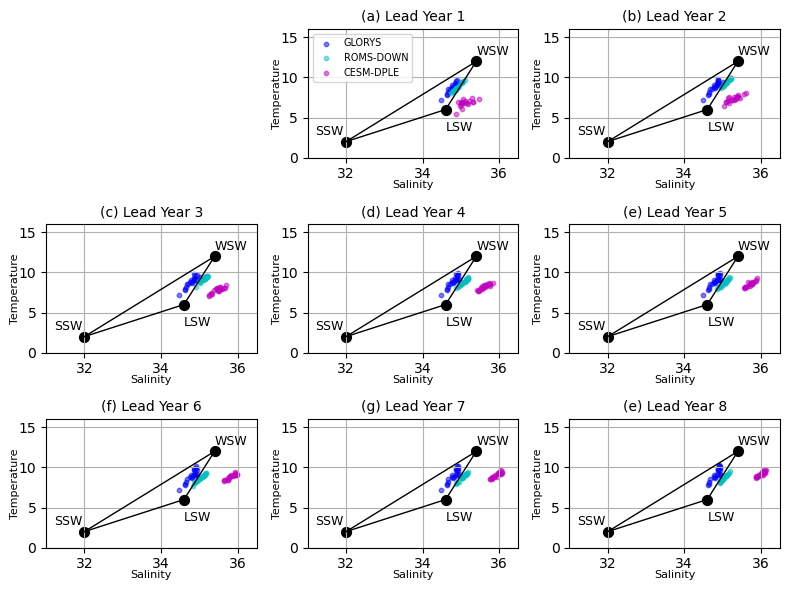

In [17]:
markers = ['o', 's', '^', 'D', 'v', 'P']  # one marker per year
labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(e)']
fig = plt.figure(figsize=(8,6)); fs=6; ms=10;lw=1;
fs=10; ms=10;
for fy in range(len(FY)):
    fig.add_subplot(3,3,fy+2)
    if fy==0:
        plt.scatter(salt_slope_glorys[1::, fy], temp_slope_glorys[1::,fy], s=ms, alpha=0.5, c='blue',label='GLORYS')  
        plt.scatter(salt_slope_roms[1::,fy], temp_slope_roms[1::,fy], s=ms, alpha=0.5, c='c',label='ROMS-DOWN')
        plt.scatter(salt_slope_dple[1::,fy], temp_slope_dple[1::,fy], s=ms, alpha=0.5, c='m',label='CESM-DPLE')
    else: 
        plt.scatter(salt_slope_glorys[:,fy], temp_slope_glorys[:,fy], s=ms, alpha=0.5, c='blue',label='GLORYS')  
        plt.scatter(salt_slope_roms[:,fy], temp_slope_roms[:,fy], s=ms, alpha=0.5, c='c',label='ROMS-DOWN')
        plt.scatter(salt_slope_dple[:,fy], temp_slope_dple[:,fy], s=ms, alpha=0.5, c='m',label='CESM-DPLE')
    if fy==0:
        plt.legend(loc='upper left',fontsize=fs-3)

    plt.xlabel('Salinity',labelpad=-1,fontsize=fs-2)
    plt.ylabel('Temperature',labelpad=-1,fontsize=fs-2)
    plt.grid(True)
    plt.xlim(31,36.5);plt.ylim(0,16);
    Salt_LSW = 34.6; Temp_LSW = 6;
    plt.scatter(Salt_LSW,Temp_LSW,s=50,c='k') #LSW
    plt.text(34.6, 3., 'LSW', fontsize=fs-1, ha='left', va='bottom')
    Salt_WSW = 35.4; Temp_WSW = 12;
    plt.scatter(Salt_WSW,Temp_WSW,s=50,c='k') ##WSW
    plt.text(35.4, 12.4, 'WSW', fontsize=fs-1, ha='left', va='bottom')
    Salt_SSW = 32; Temp_SSW = 2;
    plt.scatter(Salt_SSW,Temp_SSW,s=50,c='k') ##SSW
    plt.text(31.2,2.5, 'SSW', fontsize=fs-1, ha='left', va='bottom')
    plt.plot([Salt_LSW,Salt_WSW], [Temp_LSW,Temp_WSW], color='k', linewidth=1);
    plt.plot([Salt_WSW,Salt_SSW], [Temp_WSW,Temp_SSW], color='k', linewidth=1);
    plt.plot([Salt_SSW,Salt_LSW], [Temp_SSW,Temp_LSW], color='k', linewidth=1);
    plt.title(labels[fy]+' Lead Year '+str(FY[fy]),fontsize=fs)
plt.tight_layout()



<font size=5> Figure 15 Prediction Skill of GOM Mixing ratio

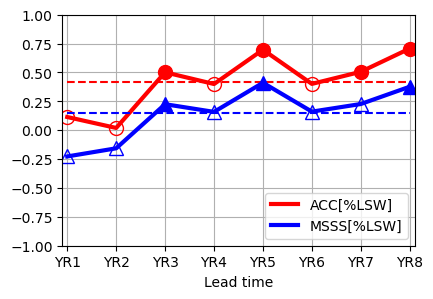

In [18]:
lw=3;ms=10;
titles = ['[ROMS-DOWN]','[ROMS-DOWN]']
plt.figure(figsize=(10,3))
src = 'roms'
plt.subplot(1,2,1);
plt.plot(vars()['acc_LSW_'+src],'r',linewidth=lw,markersize=ms,label='ACC[%LSW]');
plt.plot(np.ones(vars()['acc_LSW_'+src].size)*np.mean(vars()['acc_LSW_'+src]),'--r');
for x, y, p in zip(np.arange(acc_LSW_roms.size), acc_LSW_roms, pacc_LSW_roms):
    if p <= 0.05:
        mfc = 'r'      # filled marker
    else:
        mfc = 'none'   # empty marker
    plt.plot(x, y,marker='o',linestyle='none',markeredgecolor='r',markerfacecolor=mfc,markersize=ms,linewidth=lw) 
 
plt.plot(vars()['msss_LSW_'+src],'b',linewidth=lw,markersize=ms,label='MSSS[%LSW]');
plt.plot(np.ones(vars()['msss_LSW_'+src].size)*np.mean(vars()['msss_LSW_'+src]),'--b');
for x, y, p in zip(np.arange(msss_LSW_roms.size), msss_LSW_roms, pmsss_LSW_roms):
    if p <= 0.05:
        mfc = 'b'      # filled marker
    else:
        mfc = 'none'   # empty marker
    plt.plot(x, y,marker='^',linestyle='none',markeredgecolor='b',markerfacecolor=mfc,markersize=ms,linewidth=lw) 
# plt.plot(vars()['acc_SSW_'+src],'-ob',linewidth=lw,markersize=ms,label='[%SSW]');
# plt.plot(np.ones(vars()['acc_SSW_'+src].size)*np.mean(vars()['acc_SSW_'+src]),'--b');
# plt.plot(vars()['acc_WSW_'+src],'-ok',linewidth=lw,markersize=ms,label='[%WSW]');
# plt.plot(np.ones(vars()['acc_WSW_'+src].size)*np.mean(vars()['acc_WSW_'+src]),'--k');
plt.ylim(-1,1);plt.xlim(-0.1,7.1);plt.grid();
plt.xticks(np.arange(0,8,1),[f'YR{y+1}' for y in np.arange(0,8,1)]);
plt.xlabel('Lead time');plt.legend(loc='lower right');
# plt.title(titles[0])
# plt.subplot(1,2,2);
# # plt.plot(vars()['msss_SSW_'+src],'-ob',linewidth=lw,markersize=ms,label='[%SSW]');
# # plt.plot(np.ones(vars()['msss_SSW_'+src].size)*np.mean(vars()['msss_SSW_'+src]),'--b');
# # plt.plot(vars()['msss_WSW_'+src],'-ok',linewidth=lw,markersize=ms,label='[%WSW]');
# # plt.plot(np.ones(vars()['msss_WSW_'+src].size)*np.mean(vars()['msss_WSW_'+src]),'--k');
# plt.ylim(-1,1);plt.xlim(-0.1,7.1);plt.grid();
# plt.xticks(np.arange(0,8,1),[f'YR{y+1}' for y in np.arange(0,8,1)]);
# plt.xlabel('Lead time');plt.ylabel('MSSS');plt.legend(loc='lower right');
# plt.title(titles[1])
# plt.tight_layout()


<font size=5> Figure 16 1998 Freshening Event Analysis

In [19]:
####check SSS anomaly field with velocity
fy = 3;
years = np.arange(1994,2000,1)
dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
ssh_roms_mean = 100*dataset.variables['ssh_roms'][:,fy-1,:,:]#*all_mask
ssh_dple_mean = 100*dataset.variables['ssh_dple'][:,fy-1,:,:]#*all_mask
ssh_glorys_mean = 100*dataset.variables['ssh_glorys'][:,fy-1,:,:]#*all_mask
dataset.close();

def calculate_geostrophy(eta,lat,lon):
    #eta:time,lat,lon
    g = 9.81; Omega = 7.292115e-5; Re = 6371000.0  # Earth radius (m)
    eta = np.array(eta/100)  # ensure numpy array (time, y, x)
    phi = np.deg2rad(lat); f = 2 * Omega * np.sin(phi)

    dlat = np.gradient(np.deg2rad(lat), axis=0)
    dlon = np.gradient(np.deg2rad(lon), axis=1)

    dy = Re * dlat                          # (y,x) meters per grid step in y-direction
    dx = Re * np.cos(phi) * dlon            # (y,x) meters per grid step in x-direction

    deta_dy = np.gradient(eta, axis=1) / dy[None, :, :]
    deta_dx = np.gradient(eta, axis=2) / dx[None, :, :]

    f_safe = np.where(np.abs(f) < 1e-8, np.nan, f)

    ug = -(g / f_safe)[None, :, :] * deta_dy
    vg =  (g / f_safe)[None, :, :] * deta_dx
    ug[np.where(np.abs(ug)>10)] = np.nan
    vg[np.where(np.abs(vg)>10)] = np.nan
    
    return ug, vg

u_roms,v_roms = calculate_geostrophy(ssh_roms_mean,lat_rho,lon_rho)
u_glorys,v_glorys = calculate_geostrophy(ssh_glorys_mean,lat_rho,lon_rho)
u_dple,v_dple = calculate_geostrophy(ssh_dple_mean,lat_rho,lon_rho)


In [21]:
# Endmembers in (S, T)
LSW = np.array([34.6,  6.0], dtype=float)
WSW = np.array([35.4, 12.0], dtype=float)
SSW = np.array([32.0,  2.0], dtype=float)
def mixing_ratio(T, S):
    LSW = np.array([34.6, 6.0]); WSW = np.array([35.4, 12.0]); SSW = np.array([32.0, 2.0]);
    A = np.array([S, T])
    # Line from SSW to A: y = m1*x + b1
    m1 = (T - SSW[1]) / (S - SSW[0])
    b1 = SSW[1] - m1 * SSW[0]
    # Line from LSW to WSW: y = m2*x + b2
    m2 = (WSW[1] - LSW[1]) / (WSW[0] - LSW[0])
    b2 = WSW[1] - m2 * WSW[0]
    # Intersection point B: solve m1*x + b1 = m2*x + b2
    xB = (b2 - b1) / (m1 - m2)
    yB = m1 * xB + b1
    B = np.array([xB, yB])
    # Percent slope water (between LSW and WSW)
    dist_LSW_WSW = np.linalg.norm(WSW - LSW)
    dist_LSW_B = np.linalg.norm(B - LSW)
    dist_WSW_B = np.linalg.norm(B - WSW)
    pct_LSW = (dist_WSW_B / dist_LSW_WSW) * 100
    pct_WSW = (dist_LSW_B / dist_LSW_WSW) * 100
    # Percent shelf water (between A and B)
    dist_SSW_B = np.linalg.norm(B - SSW)
    dist_A_B = np.linalg.norm(A - B)
    pct_SSW = (dist_A_B / dist_SSW_B) * 100
    return pct_LSW, pct_WSW, pct_SSW

def calculate_acc(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]
    n = len(x)
    x_anom = x - np.mean(x)
    y_anom = y - np.mean(y)
    numerator = np.sum(x_anom * y_anom)
    denominator = np.sqrt(np.sum(x_anom ** 2) * np.sum(y_anom ** 2))
    acc = numerator / denominator if denominator != 0 else np.nan
    # Calculate t-statistic and p-value
    t_stat = acc * np.sqrt((n - 2) / (1 - acc ** 2))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 2))
    return acc, p_value
def calculate_msss1d(data1, data2):
    valid_mask = ~np.isnan(data1) & ~np.isnan(data2)
    model = data1[valid_mask]
    obs = data2[valid_mask]
    mse_forecast = np.mean((model - obs) ** 2)
    mse_climatology = np.mean(obs ** 2)
    msss = 1 - (mse_forecast / mse_climatology)
    return msss

dataset = nc.Dataset('/proj/nes/post_processed/GLORYS_slopewater_mixing_ratio_150_200m_1993_2019.nc','r')
temp_slope_glorys0 = np.mean(dataset.variables['temp_slope'][:],axis=1) ###depth mean (two levels in 150-200)
salt_slope_glorys0 = np.mean(dataset.variables['salt_slope'][:],axis=1)
dataset.close();
dataset = nc.Dataset('/proj/nes/post_processed/ROMS_Downscaling_slopewater_mixing_ratio_150_200m_SY'+str(Start_years[0])+'_SY'+str(Start_years[-1])+'_LY1_8.nc','r')
temp_slope_roms = np.mean(dataset.variables['temp_slope'][:],axis=1) #ensemble mean
salt_slope_roms = np.mean(dataset.variables['salt_slope'][:],axis=1)
dataset.close();

dataset = nc.Dataset('/proj/nes/post_processed/DPLE40_slopewater_mixing_ratio_150_200m_SY'+str(Start_years[0])+'_SY'+str(Start_years[-1])+'_LY1_8.nc','r')
temp_slope_dple = np.mean(dataset.variables['temp_slope'][:],axis=1) #ensemble mean
salt_slope_dple = np.mean(dataset.variables['salt_slope'][:],axis=1)
dataset.close();

glorys_years = np.arange(1993,2020,1);
temp_slope_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
salt_slope_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
for i,start_yr in enumerate(Start_years):
    for j, fy in enumerate(FY):
        real_year = start_yr+fy-1;
        if real_year in glorys_years:
            idx = np.where(glorys_years == real_year)[0][0]
            temp_slope_glorys[i,j] = temp_slope_glorys0[idx]
            salt_slope_glorys[i,j] = salt_slope_glorys0[idx]            
    
percent_LSW_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
percent_WSW_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
percent_SSW_glorys = np.nan*np.zeros((len(Start_years),len(FY)));
percent_LSW_roms = np.nan*np.zeros((len(Start_years),len(FY)));
percent_WSW_roms = np.nan*np.zeros((len(Start_years),len(FY)));
percent_SSW_roms = np.nan*np.zeros((len(Start_years),len(FY)));
percent_LSW_dple = np.nan*np.zeros((len(Start_years),len(FY)));
percent_WSW_dple = np.nan*np.zeros((len(Start_years),len(FY)));
percent_SSW_dple = np.nan*np.zeros((len(Start_years),len(FY)));
for i,start_yr in enumerate(Start_years):
    for j, fy in enumerate(FY):
        percent_LSW_glorys[i,j],percent_WSW_glorys[i,j],percent_SSW_glorys[i,j] = mixing_ratio(temp_slope_glorys[i,j],salt_slope_glorys[i,j])
        percent_LSW_roms[i,j],percent_WSW_roms[i,j],percent_SSW_roms[i,j] = mixing_ratio(temp_slope_roms[i,j],salt_slope_roms[i,j])
        percent_LSW_dple[i,j],percent_WSW_dple[i,j],percent_SSW_dple[i,j] = mixing_ratio(temp_slope_dple[i,j],salt_slope_dple[i,j])
        
lat_north1 = 51; lat_north2 = 52;
ilat_north = np.where((lat_rho<=lat_north2)&(lat_rho>=lat_north1))[0]
lat_south1 = 29; lat_south2 = 30;
ilat_south = np.where((lat_rho<=lat_south2)&(lat_rho>=lat_south1))[0]

dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc');
for region in ['north','south']:
    j1=vars()['ilat_'+region][0]; j2=vars()['ilat_'+region][-1];
    vars()['data_glorys_'+region] = np.nanmean(dataset.variables['sss_glorys_anomaly'][:,:,j1:j2,:],axis=(2,3))
    vars()['data_roms_'+region] = np.nanmean(dataset.variables['sss_roms_anomaly'][:,:,j1:j2,:],axis=(2,3))
    vars()['data_dple_'+region] = np.nanmean(dataset.variables['sss_dple_anomaly'][:,:,j1:j2,:],axis=(2,3))
dataset.close();
nao_data = np.loadtxt('/vortexfs1/home/yiming.guo/analysis_figures/NES_Downscaling/nao_station_djfm.txt')
nao_years = nao_data[:, 0].astype(int)
nao0 = nao_data[:, 1]


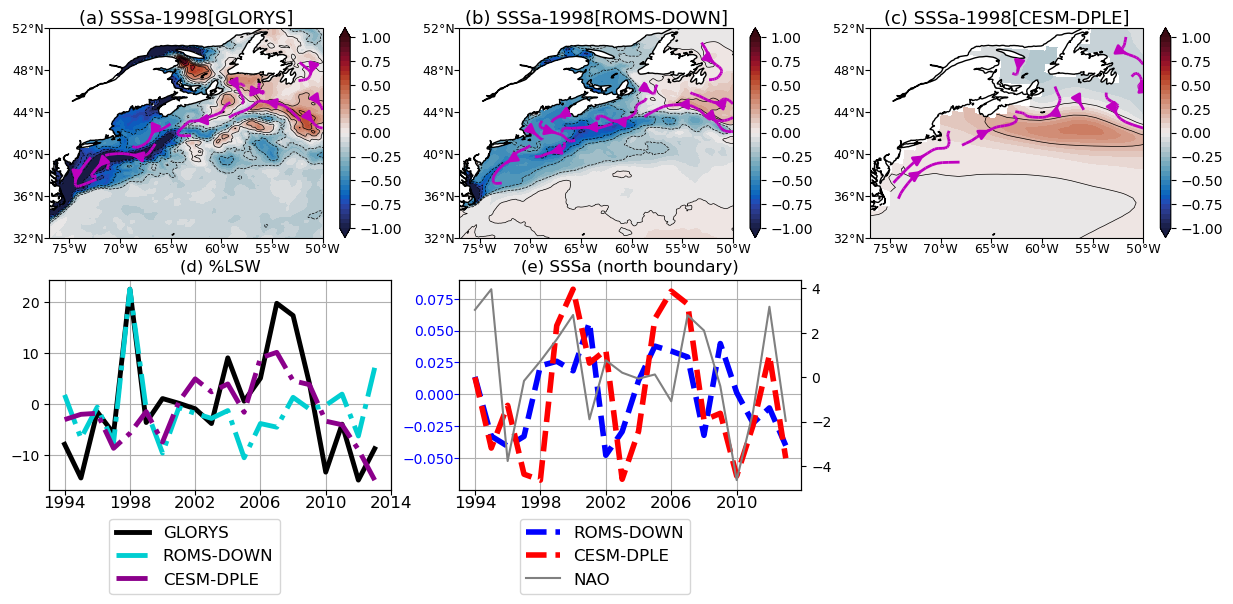

In [26]:
h0 = 4000
mask = h[:,:] > h0  # (y, x)
u_roms[:, mask] = np.nan; v_roms[:, mask] = np.nan
u_glorys[:, mask] = np.nan; v_glorys[:, mask] = np.nan
u_dple[:, mask] = np.nan; v_dple[:, mask] = np.nan

fig = plt.figure(figsize=(15,6)); fs=13; leap = 20; lw=1; pd=0;
sy = 4; fy = 3;
year = Start_years[sy]+fy-1
dataset = nc.Dataset('/proj/nes/post_processed/Ensemble_mean_data_and_anomaly_GLORYS_ROMS_DPLE_LE_SY1992_SY2011_LY1_8_LargeRegion.nc','r')
sss_roms_mean = dataset.variables['sss_roms_anomaly'][sy,fy-1,:,:]#*all_mask
sss_glorys_mean = dataset.variables['sss_glorys_anomaly'][sy,fy-1,:,:]#*all_mask
sss_dple_mean = dataset.variables['sss_dple_anomaly'][sy,fy-1,:,:]#*all_mask
dataset.close();

m=fig.add_subplot(2,3,1,projection=ccrs.PlateCarree(central_longitude=-180))
cont = m.contourf(lon_rho,lat_rho,sss_glorys_mean,np.linspace(-1,1,41),cmap=cm.balance,extend='both',transform = ccrs.PlateCarree());
plt.colorbar(cont);
# for r in ['GOM','MAB','GB']:#['all','SMAB','NMAB','WGOM','EGOM','GB']:
#     polygon_outline = patches.Polygon(vars()[r+'_coords'],closed=True, edgecolor='k', linewidth=2, facecolor='none',transform = ccrs.PlateCarree())
#     m.add_patch(polygon_outline);
m.contour(lon_rho,lat_rho,sss_glorys_mean,np.arange(-1,1,0.2),colors='k',linewidths=lw-0.5,transform = ccrs.PlateCarree());
m.coastlines();m.set_aspect('auto', adjustable=None)
m.set_xticks(np.arange(285,325,5),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-4,pad=pd);
m.set_yticks(np.arange(32,56,4),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-4,pad=pd);
m.set_extent([-77,-50,32,52],crs=ccrs.PlateCarree()); 
plt.title('(a) SSSa-'+str(year)+ '[GLORYS]',fontsize=fs,pad=pd);
#m.text(-76.5,50.5,'(a)',fontsize=fs,transform=ccrs.PlateCarree())
m.streamplot(lon_rho[0, :],lat_rho[:, 0],u_glorys[sy, :, :],v_glorys[sy, :, :],transform=ccrs.PlateCarree(),density=0.8,color='m',arrowsize=1.5,minlength=0.25,zorder=3,linewidth=2)    

m=fig.add_subplot(2,3,2,projection=ccrs.PlateCarree(central_longitude=-180))
cont = m.contourf(lon_rho,lat_rho,sss_roms_mean,np.linspace(-1,1,41),cmap=cm.balance,extend='both',transform = ccrs.PlateCarree());
plt.colorbar(cont);
m.contour(lon_rho,lat_rho,sss_roms_mean,np.arange(-1,1,0.2),colors='k',linewidths=lw-0.5,transform = ccrs.PlateCarree());
m.coastlines();m.set_aspect('auto', adjustable=None)
m.set_xticks(np.arange(285,325,5),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-4,pad=pd);
m.set_yticks(np.arange(32,56,4),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-4,pad=pd);
m.set_extent([-77,-50,32,52],crs=ccrs.PlateCarree()); 
plt.title('(b) SSSa-'+str(year)+ '[ROMS-DOWN]',fontsize=fs,pad=pd);
#m.text(-76.5,50.5,'(b)',fontsize=fs,transform=ccrs.PlateCarree())
m.streamplot(lon_rho[0, :],lat_rho[:, 0],u_roms[sy, :, :],v_roms[sy, :, :],transform=ccrs.PlateCarree(),density=0.8,color='m',arrowsize=1.5,minlength=0.25,zorder=3,linewidth=2)    

m=fig.add_subplot(2,3,3,projection=ccrs.PlateCarree(central_longitude=-180))
cont = m.contourf(lon_rho,lat_rho,sss_dple_mean,np.linspace(-1,1,41),cmap=cm.balance,extend='both',transform = ccrs.PlateCarree());
plt.colorbar(cont);
m.contour(lon_rho,lat_rho,sss_dple_mean,np.arange(-1,1,0.2),colors='k',linewidths=lw-0.5,transform = ccrs.PlateCarree());
m.coastlines();m.set_aspect('auto', adjustable=None)
m.set_xticks(np.arange(285,325,5),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params(labelsize=fs-4,pad=pd);
m.set_yticks(np.arange(32,56,4),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params(labelsize=fs-4,pad=pd);
m.set_extent([-77,-50,32,52],crs=ccrs.PlateCarree()); 
plt.title('(c) SSSa-'+str(year)+ '[CESM-DPLE]',fontsize=fs,pad=pd);
#m.text(-76.5,50.5,'(c)',fontsize=fs,transform=ccrs.PlateCarree())
m.streamplot(lon_rho[0, :],lat_rho[:, 0],u_dple[sy, :, :],v_dple[sy, :, :],transform=ccrs.PlateCarree(),density=0.8,color='m',arrowsize=1.5,minlength=0.25,zorder=3,linewidth=2)    


fy = 3;
years = np.arange(1994,2000,1)

lw=3.5; fs=12;
varia = 'LSW'
ax1=fig.add_subplot(2,3,4)
detrended = signal.detrend(vars()['percent_'+varia+'_glorys'][:,fy-FY[0]])
ax1.plot(Start_years+fy-FY[0],detrended,'k',linewidth=lw,label='GLORYS');
ax1.grid();
ax1.set_xticks(np.arange(1994,2016,4))
#ax1.text(1994,20.5,'(d)',fontsize=fs);
ax1.set_title('(d) %LSW',fontsize=fs)
ax1.tick_params(axis='x', labelsize=fs,pad=0.5)
ax2 = ax1.twinx();
detrended = signal.detrend(vars()['percent_'+varia+'_roms'][:,fy-FY[0]])
ax2.plot(Start_years+fy-FY[0],detrended,'darkturquoise',linestyle='-.',linewidth=lw,label='ROMS-DOWN');
detrended = signal.detrend(vars()['percent_'+varia+'_dple'][:,fy-FY[0]])
ax2.plot(Start_years+fy-FY[0],detrended,'darkmagenta',linestyle='-.',linewidth=lw,label='CESM-DPLE');
ax2.tick_params(axis='y', colors='b',pad=0.5)
ax2.set_xticks(np.arange(1994,2016,4))
ax2.set_yticks([]);

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=fs,bbox_to_anchor=(0.7,-0.1));


fy = 3;
years = Start_years+fy-FY[0]

lw=4; fs=12;

for r,region in enumerate(['north']):
    ax1=fig.add_subplot(2,3,5)
    ax1.grid();
    ax1.set_title('(e) SSSa ('+region+' boundary)',fontsize=fs);
    ax1.tick_params(axis='x', labelsize=fs,pad=0.5)
    detrended = signal.detrend(vars()['data_roms_'+region][:,fy-FY[0]])
    ax1.plot(years,detrended,'--b',linewidth=lw,label='ROMS-DOWN');
    detrended = signal.detrend(vars()['data_dple_'+region][:,fy-FY[0]])
    ax1.plot(years,detrended,'--r',linewidth=lw,label='CESM-DPLE');
    ax1.tick_params(axis='y', colors='b',pad=0.5)
    ax1.set_xticks(np.arange(1994,2016,4))
    
    if region =='north':
        ax2 = ax1.twinx();
        ax2.plot(nao_years[years[0]-nao_years[0]:years[-1]-nao_years[0]+1],nao0[years[0]-nao_years[0]:years[-1]-nao_years[0]+1],'grey',label='NAO')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=fs,bbox_to_anchor=(0.7, -0.1))
